<a href="https://colab.research.google.com/github/audreybyrne03/HSE751-Final-Project/blob/main/Diabetes_Readmission_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting 30-Day Hospital Readmission Among Patients With Diabetes

**HSE 751: Programming for Health Data Science**  
**Final Project Pipeline** (Week 4 Final Project Checkpoint; builds on the Week 3 Dataset Selection and Final Project Planning Lab)

## 1. Data Selection

### Dataset

**Dataset:** Diabetes 130-US Hospitals for Years 1999–2008  
**Source:** UCI Machine Learning Repository  
**Source URL:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008  
**Project data file:** `diabetic_data.csv`, the original file distributed by UCI (dataset ID 296), stored in this project's GitHub repository

### Dataset Selection and Justification

For my final project, I selected the **Diabetes 130-US Hospitals for Years 1999–2008** dataset from the UCI Machine Learning Repository. The dataset contains over 100,000 hospital encounters for patients with diabetes and includes demographic, clinical, medication, and healthcare utilization information.

I selected this dataset because it supports a clinically meaningful prediction problem: identifying hospital encounters at risk of readmission within 30 days. Early hospital readmission is an important clinical outcome and provides an opportunity to examine how multiple types of patient-level healthcare data can contribute to risk prediction. The project also aligns with my interests in clinical outcomes research, healthcare utilization, and the application of data science to patient-level clinical data.

Beyond the specific prediction problem, I plan to use this dataset as the initial demonstration of a reproducible clinical outcomes analytics pipeline. The longer-term goal is to organize the workflow so that data validation, preprocessing, statistical analysis, model training, and model evaluation can eventually be adapted to other compatible patient-level clinical datasets.

### Project Criteria

This dataset satisfies the requirements for the final project:

- **Binary classification:** The original readmission outcome will be transformed into a binary target indicating readmission within 30 days versus no readmission within 30 days.
- **Minimum of 300 observations:** The dataset contains more than 100,000 hospital encounters.
- **Minimum of 10 predictor variables:** The dataset contains substantially more than 10 candidate demographic, clinical, medication, and healthcare utilization variables.
- **Relevant subject area:** The dataset supports a clinically meaningful health outcomes prediction problem that aligns with my academic and research interests.

## 2. Data Import and Validation

The dataset is loaded from `diabetic_data.csv`, the original file distributed by the UCI Machine Learning Repository (dataset ID 296) and stored in this project's GitHub repository. It contains the same 101,766 encounters and the same 47 predictor variables as the `ucimlrepo` version used in Week 3. It also retains two identifier columns, `encounter_id` and `patient_nbr`, which `ucimlrepo` omits. `patient_nbr` is needed so that the same patient does not appear in both the training and test data.

The notebook loads the file from the Colab session if it has been uploaded, and otherwise directly from GitHub, so it can be run from start to finish without manual file handling.

### Enhancement 1: Data Contract and Automated Validation

**What was modified:** All dataset-specific expectations (data source, expected columns, target values, allowed category levels, plausible numeric ranges, and missing-value codes) were moved into a single `DATA_CONTRACT` dictionary. Two reusable functions were added: `load_data()` and `validate_data()`, plus `report_validation()` to display the results.

**Why it was implemented:** In Week 3, data loading and checks were hard-coded throughout the notebook. Any problem in the data, such as a renamed column or an unexpected category, would only show up later as a confusing error in a downstream step.

**How it improves the workflow:** The pipeline now checks the data immediately after import and stops with a clear message if critical expectations are not met, while non-critical issues are reported as warnings. Because the expectations live in one place, adapting the pipeline to another compatible clinical dataset requires editing the contract rather than the analysis code.

In [1]:
# Import packages used throughout the pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# =============================================================================
# DATA CONTRACT
# All dataset-specific expectations live here. To adapt the pipeline to another
# compatible dataset, edit this dictionary rather than the analysis code.
# =============================================================================
DATA_CONTRACT = {
    # Data source: a local copy in the Colab session is used first; the GitHub
    # copy is used as a fallback.
    "local_path": "diabetic_data.csv",
    "remote_url": "https://raw.githubusercontent.com/audreybyrne03/HSE751-Final-Project/main/diabetic_data.csv",

    # Structure
    "expected_n_columns": 50,
    "id_columns": ["encounter_id", "patient_nbr"],

    # Outcome
    "target_column": "readmitted",
    "target_allowed_values": {"NO", ">30", "<30"},
    "positive_class_value": "<30",

    # In the raw UCI file, "?" means missing. The text "None" in the two lab
    # columns means "test not performed" and is kept as a real category.
    "missing_value_codes": ["?"],

    # Plausible ranges for numeric variables (values outside trigger a warning)
    "numeric_ranges": {
        "time_in_hospital":   (1, 14),
        "num_lab_procedures": (0, 200),
        "num_procedures":     (0, 10),
        "num_medications":    (0, 100),
        "number_outpatient":  (0, 100),
        "number_emergency":   (0, 100),
        "number_inpatient":   (0, 100),
        "number_diagnoses":   (1, 20),
    },

    # Integer-coded variables that represent categories, not quantities
    "coded_categorical_columns": [
        "admission_type_id", "discharge_disposition_id", "admission_source_id"
    ],

    # Allowed levels for key categorical variables
    "categorical_allowed_values": {
        "gender": {"Female", "Male", "Unknown/Invalid"},
        "age": {"[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
                "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"},
        "max_glu_serum": {"None", "Norm", ">200", ">300"},
        "A1Cresult": {"None", "Norm", ">7", ">8"},
        "change": {"No", "Ch"},
        "diabetesMed": {"No", "Yes"},
    },
}

In [3]:
def load_data(contract):
    """Load the dataset from a local file if present, otherwise from GitHub."""
    local_path = Path(contract["local_path"])
    read_kwargs = dict(
        na_values=contract["missing_value_codes"],  # convert "?" to NaN
        keep_default_na=False,                      # keep the text "None" as a category
        low_memory=False,                           # avoids the mixed-type warning
    )
    source = str(local_path) if local_path.exists() else contract["remote_url"]

    try:
        df = pd.read_csv(source, **read_kwargs)
    except Exception as error:
        raise FileNotFoundError(
            f"Could not load the dataset from '{source}'. Upload diabetic_data.csv "
            f"to the Colab session or check the GitHub URL in DATA_CONTRACT.\n{error}"
        )

    print(f"Loaded dataset from: {source}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df


raw_df = load_data(DATA_CONTRACT)
raw_df.head()

Loaded dataset from: https://raw.githubusercontent.com/audreybyrne03/HSE751-Final-Project/main/diabetic_data.csv
Shape: 101,766 rows x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
def validate_data(df, contract):
    """Check the dataset against the data contract.
    Returns a dictionary of critical errors and non-critical warnings."""
    errors, warnings = [], []

    # 1. Structure
    if df.shape[1] != contract["expected_n_columns"]:
        errors.append(f"Expected {contract['expected_n_columns']} columns, found {df.shape[1]}.")

    required = (contract["id_columns"] + [contract["target_column"]]
                + list(contract["numeric_ranges"]) + contract["coded_categorical_columns"]
                + list(contract["categorical_allowed_values"]))
    missing_cols = [c for c in required if c not in df.columns]
    if missing_cols:
        errors.append(f"Missing required columns: {missing_cols}")
        return {"errors": errors, "warnings": warnings}  # cannot continue checking

    # 2. Each encounter should appear once
    if df["encounter_id"].duplicated().any():
        errors.append(f"{df['encounter_id'].duplicated().sum()} duplicate encounter_id values.")

    # 3. Target values
    target = df[contract["target_column"]]
    unexpected = set(target.dropna().unique()) - contract["target_allowed_values"]
    if unexpected:
        errors.append(f"Unexpected target values: {unexpected}")
    if target.isna().any():
        errors.append("Target column contains missing values.")

    # 4. Numeric type and plausible range
    for col, (low, high) in contract["numeric_ranges"].items():
        if not pd.api.types.is_numeric_dtype(df[col]):
            errors.append(f"'{col}' should be numeric but is {df[col].dtype}.")
            continue
        n_out = ((df[col] < low) | (df[col] > high)).sum()
        if n_out:
            warnings.append(f"'{col}': {n_out} values outside expected range [{low}, {high}].")

    # 5. Categorical levels
    for col, allowed in contract["categorical_allowed_values"].items():
        unexpected = set(df[col].dropna().unique()) - allowed
        if unexpected:
            errors.append(f"'{col}' contains unexpected values: {unexpected}")

    # 6. Repeated patients (informational; handled later by splitting on patient)
    n_patients = df["patient_nbr"].nunique()
    if n_patients < len(df):
        warnings.append(f"{len(df):,} encounters come from {n_patients:,} unique patients "
                        f"({len(df) - n_patients:,} repeat encounters). "
                        f"Train/test split must be done by patient.")

    return {"errors": errors, "warnings": warnings}


def report_validation(results):
    """Print the validation report and stop the pipeline if critical errors exist."""
    print("DATA VALIDATION REPORT")
    print("=" * 60)
    for w in results["warnings"]:
        print(f"  WARNING: {w}")
    for e in results["errors"]:
        print(f"  ERROR:   {e}")
    if results["errors"]:
        raise ValueError(f"Validation failed with {len(results['errors'])} error(s). See report above.")
    print(f"  PASSED: no critical errors ({len(results['warnings'])} warning(s) to review).")


report_validation(validate_data(raw_df, DATA_CONTRACT))

DATA VALIDATION REPORT
  PASSED: no critical errors (1 warning(s) to review).


In [5]:
# Separate the 47 predictor variables from the original outcome.
# Identifier columns are kept in raw_df (needed later for the patient-level split)
# but excluded from the predictors.
ID_COLUMNS = DATA_CONTRACT["id_columns"]
TARGET_COLUMN = DATA_CONTRACT["target_column"]

X = raw_df.drop(columns=ID_COLUMNS + [TARGET_COLUMN]).copy()
y = raw_df[[TARGET_COLUMN]].copy()

print(f"Predictor data shape: {X.shape}")
print(f"Target data shape: {y.shape}")

Predictor data shape: (101766, 47)
Target data shape: (101766, 1)


## 3. Dataset Structure

The imported dataset contains **101,766 hospital encounters**, **47 predictor variables**, and **1 target variable**. Before defining the final binary prediction outcome or performing preprocessing, the raw dataset structure is examined to understand the available variables, data types, and example observations.

In Week 3, the `ucimlrepo` import generated a mixed-data-type warning for one column. Loading the raw CSV with `low_memory=False` and declaring `"?"` as the missing-value code resolves this, so all count variables are read as integers and the validation step confirms their types.

In [6]:
# Display the first five rows of the predictor dataset
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [7]:
# Display the names of all predictor variables
print("Predictor variables:")
for i, column in enumerate(X.columns, start=1):
    print(f"{i}. {column}")

Predictor variables:
1. race
2. gender
3. age
4. weight
5. admission_type_id
6. discharge_disposition_id
7. admission_source_id
8. time_in_hospital
9. payer_code
10. medical_specialty
11. num_lab_procedures
12. num_procedures
13. num_medications
14. number_outpatient
15. number_emergency
16. number_inpatient
17. diag_1
18. diag_2
19. diag_3
20. number_diagnoses
21. max_glu_serum
22. A1Cresult
23. metformin
24. repaglinide
25. nateglinide
26. chlorpropamide
27. glimepiride
28. acetohexamide
29. glipizide
30. glyburide
31. tolbutamide
32. pioglitazone
33. rosiglitazone
34. acarbose
35. miglitol
36. troglitazone
37. tolazamide
38. examide
39. citoglipton
40. insulin
41. glyburide-metformin
42. glipizide-metformin
43. glimepiride-pioglitazone
44. metformin-rosiglitazone
45. metformin-pioglitazone
46. change
47. diabetesMed


In [8]:
# Examine the structure and data types of the predictor dataset
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [9]:
# Examine the original target variable supplied by UCI
print("Target variable name:")
print(y.columns.tolist())

print("\nFirst five target values:")
display(y.head())

print("\nTarget value counts:")
print(y.iloc[:, 0].value_counts(dropna=False))

Target variable name:
['readmitted']

First five target values:


,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO



Target value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## 4. Target Variable

The original target variable provided by UCI is `readmitted`. It contains three categories:

- `NO` = no recorded readmission
- `>30` = readmission more than 30 days after discharge
- `<30` = readmission within 30 days of discharge

For this project, the prediction problem is **binary classification of 30-day hospital readmission**. The original target is therefore transformed into:

\[
Y_i =
\begin{cases}
1, & \text{if patient encounter } i \text{ has readmitted = <30} \\
0, & \text{if patient encounter } i \text{ has readmitted = >30 or NO}
\end{cases}
\]

The resulting target variable, `readmitted_30d`, represents whether an encounter was followed by a readmission within 30 days.

This outcome definition focuses the classification problem on early readmission. Encounters with readmission after 30 days are included in the negative class because they did not experience the specific outcome being predicted within the 30-day window.

In [10]:
# Create the binary 30-day readmission target.
# 1 = readmitted within 30 days
# 0 = not readmitted within 30 days

readmitted_30d = (y["readmitted"] == "<30").astype(int)

# Examine the new binary target
print("Binary target value counts:")
print(readmitted_30d.value_counts().sort_index())

print("\nBinary target proportions:")
print(readmitted_30d.value_counts(normalize=True).sort_index().round(4))

Binary target value counts:
readmitted
0    90409
1    11357
Name: count, dtype: int64

Binary target proportions:
readmitted
0    0.8884
1    0.1116
Name: proportion, dtype: float64


In [11]:
# Validate the binary target
assert len(readmitted_30d) == len(X), "Target and predictor row counts do not match."
assert set(readmitted_30d.unique()) == {0, 1}, "Target must contain only 0 and 1."
assert readmitted_30d.sum() == (y["readmitted"] == "<30").sum(), \
    "Binary target does not match the original <30 readmission category."

print("Binary target validation passed.")

Binary target validation passed.


### Target Distribution

The binary outcome contains **11,357 encounters (11.16%)** with a readmission within 30 days and **90,409 encounters (88.84%)** without a readmission within 30 days.

This demonstrates substantial **class imbalance**, with approximately one in nine encounters belonging to the positive class. A classifier that simply predicted no 30-day readmission for every encounter would therefore achieve high overall accuracy despite having no ability to identify patients who experience the outcome of interest.

This imbalance will be important when selecting model evaluation metrics. For the final classification pipeline, **F1 score is proposed as the primary evaluation metric** because it combines precision and recall and therefore evaluates performance in identifying the minority positive class without relying on accuracy alone. Additional metrics can be used later to provide a more complete assessment of model performance.

## 5. Predictor Variables

The dataset contains **47 candidate predictor variables** representing multiple aspects of the patient and hospital encounter. These variables include both numerical and categorical data and can be organized into several clinically meaningful domains.

### Demographic Characteristics

- `race`
- `gender`
- `age`
- `weight`

These variables describe basic patient demographic and anthropometric characteristics.

### Hospital Encounter Characteristics

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`
- `time_in_hospital`
- `payer_code`
- `medical_specialty`

These variables describe characteristics of the hospitalization, including the type and source of admission, discharge disposition, length of stay, payer, and admitting medical specialty.

### Clinical Care and Healthcare Utilization

- `num_lab_procedures`
- `num_procedures`
- `num_medications`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`
- `number_diagnoses`

These variables quantify care delivered during the encounter and prior healthcare utilization.

### Diagnoses

- `diag_1`
- `diag_2`
- `diag_3`

These variables represent the primary and additional diagnosis codes associated with the encounter.

### Laboratory Results

- `max_glu_serum`
- `A1Cresult`

These variables provide available information about glucose and hemoglobin A1C testing.

### Diabetes Medications

The dataset contains multiple variables describing the status of individual diabetes medications, including:

`metformin`, `repaglinide`, `nateglinide`, `chlorpropamide`, `glimepiride`, `acetohexamide`, `glipizide`, `glyburide`, `tolbutamide`, `pioglitazone`, `rosiglitazone`, `acarbose`, `miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `insulin`, `glyburide-metformin`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, and `metformin-pioglitazone`.

### Overall Diabetes Treatment

- `change`
- `diabetesMed`

These variables indicate whether the diabetes medication regimen changed during the encounter and whether diabetes medication was prescribed.

Together, these predictors provide demographic, clinical, utilization, laboratory, and treatment information that may be evaluated for their relationship with 30-day hospital readmission.

## 6. Descriptive Statistics

Descriptive statistics were calculated to characterize the hospital encounters before further exploratory analysis. Because the dataset contains both numerical and categorical predictors, the variables are summarized using methods appropriate to their data types.

For numerical variables, the analysis reports the count, mean, standard deviation, median, interquartile range, minimum, and maximum. For selected categorical variables, frequency distributions are examined to understand the composition of the study population and identify potentially sparse or unusual categories.

In [12]:
# Select numerical variables that represent counts or quantities.
numeric_variables = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Calculate descriptive statistics.
numeric_summary = X[numeric_variables].describe().T

# Add the median and interquartile range (IQR).
numeric_summary["median"] = X[numeric_variables].median()
numeric_summary["IQR"] = (
    X[numeric_variables].quantile(0.75)
    - X[numeric_variables].quantile(0.25)
)

# Select and organize the statistics for display.
numeric_summary = numeric_summary[
    ["count", "mean", "std", "min", "25%", "median", "75%", "IQR", "max"]
]

numeric_summary.round(2)

,count,mean,std,min,25%,median,75%,IQR,max
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,4.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,26.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,10.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,3.0,16.0


In [13]:
# Examine frequency distributions for selected categorical predictors.
categorical_variables = [
    "race",
    "gender",
    "age",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed"
]

for variable in categorical_variables:
    print(f"\n{variable}")
    print("-" * 40)
    print(X[variable].value_counts(dropna=False))


race
----------------------------------------
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
----------------------------------------
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
----------------------------------------
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

max_glu_serum
----------------------------------------
max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

A1Cresult
----------------------------------------
A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

insulin
----------------------------------------
insulin
No   

In [14]:
# Count the number of unique observed values in each predictor.
unique_counts = X.nunique(dropna=False).sort_values()

print("Number of unique values by predictor:")
print(unique_counts)

Number of unique values by predictor:
examide                       1
citoglipton                   1
acetohexamide                 2
tolbutamide                   2
diabetesMed                   2
troglitazone                  2
metformin-rosiglitazone       2
metformin-pioglitazone        2
glipizide-metformin           2
glimepiride-pioglitazone      2
change                        2
gender                        3
tolazamide                    3
glyburide                     4
pioglitazone                  4
A1Cresult                     4
max_glu_serum                 4
glyburide-metformin           4
rosiglitazone                 4
insulin                       4
miglitol                      4
acarbose                      4
chlorpropamide                4
nateglinide                   4
metformin                     4
repaglinide                   4
glipizide                     4
glimepiride                   4
race                          6
num_procedures                7
ad

### Descriptive Statistics Interpretation

The dataset contains 101,766 hospital encounters with substantial variation in hospitalization characteristics and prior healthcare utilization. The median length of stay was **4 days** (IQR: 2–6), and encounters included a median of **44 laboratory procedures** (IQR: 31–57), **15 medications** (IQR: 10–20), and **8 recorded diagnoses** (IQR: 6–9).

Prior healthcare utilization was highly concentrated at zero. The median number of prior outpatient and emergency encounters was **0**, with an IQR of 0–0 for both variables. Prior inpatient utilization also had a median of 0, although its upper quartile was 1. The substantially higher maximum values for outpatient (42), emergency (76), and inpatient (21) utilization suggest right-skewed distributions and the presence of patients with substantially greater prior healthcare use.

The population was concentrated in older age groups, particularly ages **70–79** (n = 26,068), **60–69** (n = 22,483), and **80–89** (n = 17,197). The dataset contained 54,708 female and 47,055 male encounters, with three observations coded as `Unknown/Invalid`.

Several variables also show important patterns relevant to future preprocessing. `A1Cresult` and `max_glu_serum` are unavailable for most encounters, while the diagnosis variables (`diag_1`, `diag_2`, and `diag_3`) contain hundreds of distinct values. In contrast, `examide` and `citoglipton` each contain only one observed value and therefore provide no variation in this dataset. These characteristics will be considered during the data quality assessment and preprocessing plan.

In [15]:
# Create an analysis dataset containing predictors and the binary outcome.
analysis_df = X.copy()
analysis_df["readmitted_30d"] = readmitted_30d

print("Analysis dataset shape:", analysis_df.shape)
analysis_df.head()

Analysis dataset shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30d
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,0


## 7. Exploratory Visualizations

### 30-Day Readmission by Age Group

The first visualization examines whether the proportion of encounters followed by a 30-day readmission differs across age groups. Because `age` is recorded as ordered age intervals rather than an exact continuous age, readmission rates are calculated separately for each available age category.

In [16]:
# Define the clinical ordering of the age categories.
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

# Calculate 30-day readmission rate within each age group.
age_readmission = (
    analysis_df.groupby("age", observed=True)["readmitted_30d"]
    .agg(["mean", "count"])
    .reindex(age_order)
    .reset_index()
)

age_readmission["readmission_rate_percent"] = (
    age_readmission["mean"] * 100
)

age_readmission[["age", "count", "readmission_rate_percent"]].round(2)

,age,count,readmission_rate_percent
0,[0-10),161,1.86
1,[10-20),691,5.79
2,[20-30),1657,14.24
3,[30-40),3775,11.23
4,[40-50),9685,10.60
5,[50-60),17256,9.67
6,[60-70),22483,11.13
7,[70-80),26068,11.77
8,[80-90),17197,12.08
9,[90-100),2793,11.10


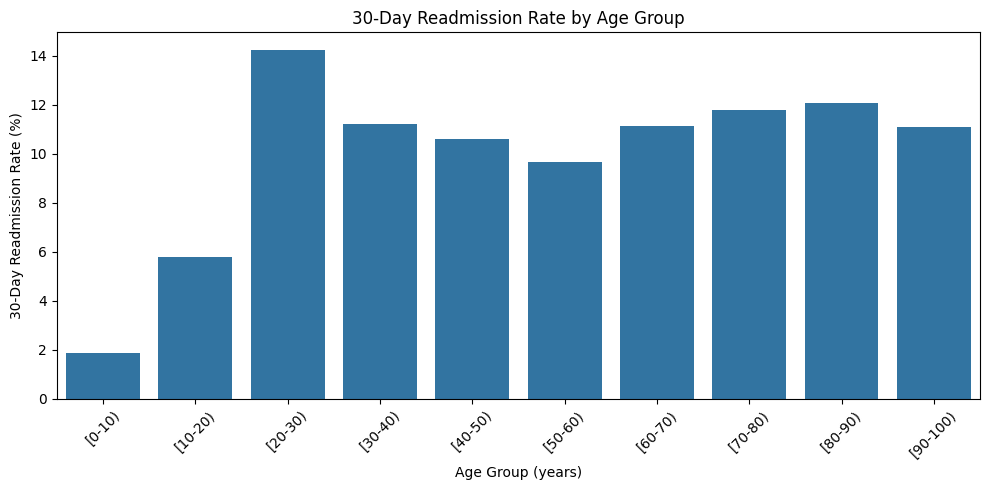

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_readmission,
    x="age",
    y="readmission_rate_percent"
)

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group (years)")
plt.ylabel("30-Day Readmission Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interpretation

Thirty-day readmission rates varied across age groups, although the relationship was not consistently linear. The lowest observed rates occurred among patients ages 0–9 (1.86%) and 10–19 (5.79%), while the highest rate occurred among patients ages 20–29 (14.24%). Among the more heavily represented adult age groups, readmission rates generally ranged from approximately 9.7% to 12.1%.

The age groups differ substantially in sample size. For example, the 0–9 age group contains only 161 encounters, compared with 26,068 encounters among patients ages 70–79. Therefore, apparent differences in the smaller age groups should be interpreted cautiously because their estimated readmission rates may be less stable.

Overall, age appears to have a potentially non-linear relationship with 30-day readmission in this dataset. This suggests that the ordered age categories may contain useful predictive information, but the exploratory results do not support assuming a simple linear increase in readmission risk with increasing age.

In [18]:
# Create categories of prior inpatient utilization for visualization.
analysis_df["prior_inpatient_group"] = pd.cut(
    analysis_df["number_inpatient"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)

# Calculate 30-day readmission rate by prior inpatient utilization.
inpatient_readmission = (
    analysis_df.groupby("prior_inpatient_group", observed=True)["readmitted_30d"]
    .agg(["mean", "count"])
    .reset_index()
)

inpatient_readmission["readmission_rate_percent"] = (
    inpatient_readmission["mean"] * 100
)

inpatient_readmission[
    ["prior_inpatient_group", "count", "readmission_rate_percent"]
].round(2)

,prior_inpatient_group,count,readmission_rate_percent
0,0,67630,8.44
1,1,19521,12.92
2,2,7566,17.43
3,3+,7049,25.66


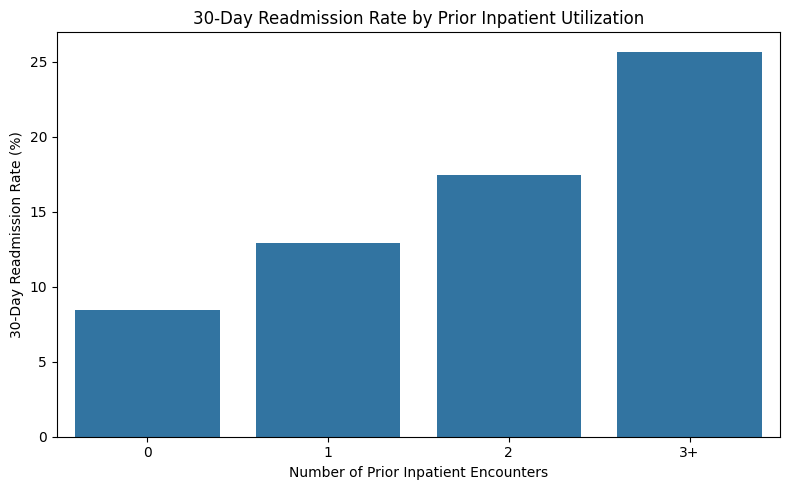

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=inpatient_readmission,
    x="prior_inpatient_group",
    y="readmission_rate_percent"
)

plt.title("30-Day Readmission Rate by Prior Inpatient Utilization")
plt.xlabel("Number of Prior Inpatient Encounters")
plt.ylabel("30-Day Readmission Rate (%)")
plt.tight_layout()
plt.show()

#### Interpretation

Prior inpatient utilization showed a clear positive relationship with 30-day readmission. Among encounters with no prior inpatient admissions, the 30-day readmission rate was **8.44%**. The rate increased to **12.92%** among patients with one prior inpatient encounter, **17.43%** among those with two, and **25.66%** among those with three or more.

This represents a substantial gradient in the observed outcome. Patients with three or more prior inpatient encounters had a 30-day readmission rate approximately three times that observed among patients with no prior inpatient utilization.

These findings suggest that prior inpatient utilization may contain useful information for predicting subsequent 30-day readmission. However, this visualization represents an unadjusted association and does not establish that prior hospitalization itself causes readmission. Other differences in disease burden, patient complexity, or healthcare utilization may contribute to the observed relationship.

## 8. Data Quality Assessment

Before developing a classification model, the dataset was evaluated for missing values, unusual coding, low-variation predictors, and other characteristics that may require preprocessing. This assessment is intended to identify potential data-quality challenges without modifying the source dataset at this stage.

In [20]:
# Calculate missingness for every predictor.
missing_summary = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percent": (X.isna().mean() * 100)
})

# Retain variables containing at least one missing value.
missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

missing_summary.round(2)

,missing_count,missing_percent
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [21]:
# Search categorical variables for common representations of
# missing, unknown, or invalid information.

object_columns = X.select_dtypes(include="object").columns

possible_missing_codes = [
    "?", "Unknown", "Unknown/Invalid",
    "Not Available", "None", "NULL"
]

for column in object_columns:
    observed_values = X[column].dropna().astype(str).unique()

    flagged_values = [
        value for value in observed_values
        if value in possible_missing_codes
    ]

    if flagged_values:
        print(f"{column}: {flagged_values}")

gender: ['Unknown/Invalid']
max_glu_serum: ['None']
A1Cresult: ['None']


In [22]:
# Identify predictors with no or very little variation.
unique_summary = pd.DataFrame({
    "unique_values": X.nunique(dropna=False),
    "most_common_percent": [
        X[col].value_counts(dropna=False, normalize=True).iloc[0] * 100
        for col in X.columns
    ]
})

unique_summary = unique_summary.sort_values(
    ["unique_values", "most_common_percent"],
    ascending=[True, False]
)

unique_summary.head(15).round(2)

,unique_values,most_common_percent
examide,1,100.00
citoglipton,1,100.00
acetohexamide,2,100.00
glimepiride-pioglitazone,2,100.00
metformin-pioglitazone,2,100.00
metformin-rosiglitazone,2,100.00
troglitazone,2,100.00
glipizide-metformin,2,99.99
tolbutamide,2,99.98
diabetesMed,2,77.00


In [23]:
# Check for exact duplicate predictor rows.
duplicate_rows = X.duplicated().sum()

print(f"Exact duplicate predictor rows: {duplicate_rows}")

Exact duplicate predictor rows: 0


### Data Quality Findings

The data quality assessment identified several issues that will need to be addressed before model development.

**Missing data:** Missingness varies substantially across predictors. `weight` is missing for **96.86%** of encounters, and `medical_specialty` (49.08%) and `payer_code` (39.56%) also have substantial missingness. Missingness is considerably lower for `race` (2.23%) and the three diagnosis variables (0.02%–1.40%). Because the amount of missing information differs substantially across variables, a single preprocessing strategy is unlikely to be appropriate for every predictor.

**Laboratory tests not performed:** In the raw UCI file, `max_glu_serum` and `A1Cresult` use the value `None` to indicate that the test was not performed during the encounter, rather than leaving the value blank. These are therefore not missing data: serum glucose was not tested in **94.75%** of encounters and HbA1c was not tested in **83.28%**. Whether a test was ordered may itself carry clinical information, so `None` is retained as its own category.

**Improper or unusual coding:** The `gender` variable contains three observations coded as `Unknown/Invalid`. These values should be treated as invalid or unknown rather than as a meaningful gender category during preprocessing.

**Low-variation predictors:** `examide` and `citoglipton` each contain only one observed value and therefore provide no information for distinguishing between outcome classes. Several additional medication variables are near-constant, including `acetohexamide`, `glimepiride-pioglitazone`, `metformin-pioglitazone`, `metformin-rosiglitazone`, and `troglitazone`. Although these variables technically contain more than one observed value, nearly 100% of encounters fall into a single category.

**Duplicate observations and repeated patients:** No exact duplicate predictor rows were identified, and each `encounter_id` appears once. However, the 101,766 encounters come from only **71,518 unique patients** (`patient_nbr`), so many patients contribute more than one encounter. This will be handled by splitting the data into training and test sets at the patient level.

Overall, the dataset is sufficiently large and information-rich for the proposed classification problem, but substantial missingness, sparse predictors, categorical coding, and potential repeated encounters will require careful preprocessing before predictive modeling.

## 9. Anticipated Preprocessing and Potential Challenges

Several preprocessing steps will be considered before training the final classification models.

### Missing Data

Variables with extremely high missingness, such as `weight`, `max_glu_serum`, and `A1Cresult`, will require careful evaluation. Variables with very little observed information may be excluded from the predictive feature set if they cannot be used reliably. For variables with more moderate missingness, missingness may itself contain clinically relevant information; therefore, categorical missing or unknown levels and missingness indicators will be considered rather than automatically deleting incomplete encounters.

### Low-Variation Features

Constant predictors such as `examide` and `citoglipton` will be removed because they contain no discriminatory information. Near-constant medication variables will also be evaluated and may be removed if their extremely limited variation is unlikely to contribute useful predictive information.

### Categorical Variables

The dataset contains numerous categorical variables that cannot be entered directly into many machine-learning algorithms. Variables such as race, gender, age group, medication status, and other categorical characteristics will require appropriate encoding. Integer-coded variables such as `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` will be treated as categorical identifiers rather than continuous numerical measurements.

### High-Cardinality Variables

The diagnosis variables (`diag_1`, `diag_2`, and `diag_3`) contain hundreds of distinct diagnosis codes, and `medical_specialty` also contains many categories. Direct one-hot encoding of every observed value could create a large and sparse feature space. These variables may require clinically meaningful grouping or other dimensionality-reduction strategies before modeling.

### Outcome Imbalance

Only **11.16%** of encounters experienced a readmission within 30 days. Because of this class imbalance, overall accuracy would provide an incomplete assessment of model performance. The project will use **F1 score as the primary evaluation metric**, with additional classification metrics reported to characterize model performance more completely.

### Potential Outcome Leakage and Cohort Definition

Predictors will be reviewed to ensure that they represent information that would reasonably be available at the intended time of prediction and do not directly reveal the future readmission outcome. Variables related to discharge disposition require particular attention because some discharge outcomes may affect whether a subsequent hospital readmission is possible or clinically meaningful.

### Repeated Patient Encounters

The source data are organized at the hospital-encounter level, so multiple encounters may potentially correspond to the same patient. For the final predictive pipeline, patient-level identifiers and the original dataset structure will be investigated so that repeated encounters can be handled appropriately and information from the same patient does not inadvertently appear in both training and test data.

### Reproducible Preprocessing

For the final project, preprocessing steps will be incorporated into a reproducible analytical pipeline. The planned workflow will define required variables and data types, validate incoming data, apply preprocessing consistently, train classification models, and evaluate performance. Where feasible, dataset-specific definitions will be separated from reusable pipeline components so that the framework can later be adapted to other compatible patient-level clinical datasets.

## 10. Project Planning

### Proposed Prediction Problem

The final project will develop a supervised binary classification model to predict **30-day hospital readmission among patients with diabetes**. The model will use demographic, clinical, medication, and healthcare utilization information available from the hospital encounter to identify encounters at increased risk of readmission within 30 days.

### Target Variable

The binary target variable is `readmitted_30d`, derived from the original UCI `readmitted` variable:

- `1` = readmitted within 30 days (`<30`)
- `0` = not readmitted within 30 days (`>30` or `NO`)

The resulting outcome is imbalanced: **11,357 encounters (11.16%)** experienced a 30-day readmission, compared with **90,409 encounters (88.84%)** without a 30-day readmission.

### Primary Evaluation Metric

The proposed primary evaluation metric is the **F1 score**:

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

F1 score is appropriate for this prediction problem because the positive class—30-day readmission—represents only 11.16% of encounters. Overall accuracy could appear high even for a model that performs poorly at identifying patients who experience a 30-day readmission.

F1 balances **precision**, the proportion of predicted readmissions that are true readmissions, and **recall**, the proportion of actual 30-day readmissions correctly identified by the model. Additional metrics, including precision, recall, confusion matrix, and area under the receiver operating characteristic curve (AUROC), may be reported as secondary measures to provide a more complete assessment of model performance.

### Final Project Direction

The diabetes readmission problem will serve as the initial implementation of a broader **reproducible clinical outcomes analytics pipeline**. The planned workflow will use a standardized data-contract approach to validate input data, preprocess predictors, perform exploratory and statistical analyses, train classification models, and evaluate model performance.

Where feasible, dataset-specific definitions such as the target and required predictors will be separated from reusable analytical components. This structure is intended to make the workflow reproducible for the current project while providing a foundation that could later be adapted to other compatible patient-level clinical outcomes datasets.

## 11. Data Cleaning and Preprocessing

This section applies the preprocessing decisions identified in Sections 8 and 9. All steps are written as reusable functions controlled by a single `PREPROCESSING_CONFIG` dictionary, so each decision is documented in one place and can be changed without editing the analysis code.

The steps are applied in this order:

1. **Cohort definition:** remove encounters that cannot experience the outcome, or that have invalid values.
2. **Target construction:** create the binary `readmitted_30d` outcome.
3. **Removal of low-information predictors:** drop predictors that are mostly missing or nearly constant, using rules rather than a hand-typed list.
4. **Feature engineering:** group diagnosis codes, convert age to an ordered numeric variable, and create summary features.

Encoding categorical variables and scaling numeric variables are **not** performed here. Those steps learn from the data (for example, which categories exist or what the mean is), so they will be fitted on the training data only, inside the machine learning pipeline, to avoid data leakage.

### 11.1 Preprocessing Configuration

In [24]:
# =============================================================================
# PREPROCESSING CONFIGURATION
# Every cleaning and feature engineering decision is set here.
# =============================================================================
PREPROCESSING_CONFIG = {
    # --- Cohort definition -------------------------------------------------
    # Discharge dispositions after which a readmission cannot occur
    # (death or discharge to hospice). Codes from the UCI IDs_mapping file.
    "exclude_discharge_codes": {
        11: "Expired",
        13: "Hospice / home",
        14: "Hospice / medical facility",
        19: "Expired at home (hospice)",
        20: "Expired in a medical facility (hospice)",
        21: "Expired, place unknown (hospice)",
    },
    # Gender value treated as invalid
    "invalid_gender_value": "Unknown/Invalid",
    # If True, keep only each patient's first encounter (lowest encounter_id).
    # If False, keep all encounters and handle repeat patients with a
    # patient-level train/test split.
    "first_encounter_only": False,

    # --- Low-information predictors -----------------------------------------
    # Drop a predictor if more than this % of values are missing
    "max_missing_percent": 90.0,
    # Drop a predictor if its most common value covers at least this % of rows
    "max_single_category_percent": 99.9,
    # Columns never removed by the automatic rules
    "protected_columns": ["encounter_id", "patient_nbr", "readmitted"],

    # --- Feature engineering -------------------------------------------------
    "diagnosis_columns": ["diag_1", "diag_2", "diag_3"],
    "missing_category_label": "Missing",
    # Keep the N most common medical specialties; group the rest as "Other"
    "top_n_specialties": 10,
}

### 11.2 Cohort Definition

Encounters that ended in death or discharge to hospice are removed, because a 30-day readmission is not possible or not clinically meaningful after these discharges. Keeping them would add encounters to the negative class that were never at risk of the outcome. The three encounters with an invalid gender value are also removed. The cohort flow table records how many encounters each rule removed and how the readmission rate changed.

In [25]:
def define_cohort(df, contract, config):
    """Apply the cohort rules and return the cohort plus a cohort flow table
    showing how many encounters each rule removed."""
    target_col = contract["target_column"]
    positive = contract["positive_class_value"]
    flow = []

    def record(step, data, removed):
        flow.append({
            "Step": step,
            "Encounters removed": removed,
            "Encounters remaining": len(data),
            "Unique patients": data["patient_nbr"].nunique(),
            "30-day readmission rate (%)": round((data[target_col] == positive).mean() * 100, 2),
        })

    cohort = df.copy()
    record("Starting dataset", cohort, 0)

    # Rule 1: remove encounters ending in death or hospice discharge
    excluded_codes = list(config["exclude_discharge_codes"])
    mask = cohort["discharge_disposition_id"].isin(excluded_codes)
    cohort = cohort.loc[~mask]
    record("Exclude death or hospice discharge", cohort, int(mask.sum()))

    # Rule 2: remove encounters with invalid gender
    mask = cohort["gender"] == config["invalid_gender_value"]
    cohort = cohort.loc[~mask]
    record("Exclude invalid gender", cohort, int(mask.sum()))

    # Rule 3 (optional): keep only each patient's first encounter
    if config["first_encounter_only"]:
        before = len(cohort)
        cohort = (cohort.sort_values("encounter_id")
                        .drop_duplicates(subset="patient_nbr", keep="first"))
        record("Keep first encounter per patient", cohort, before - len(cohort))

    cohort = cohort.reset_index(drop=True)
    return cohort, pd.DataFrame(flow)


cohort_df, cohort_flow = define_cohort(raw_df, DATA_CONTRACT, PREPROCESSING_CONFIG)
cohort_flow

,Step,Encounters removed,Encounters remaining,Unique patients,30-day readmission rate (%)
0,Starting dataset,0,101766,71518,11.16
1,Exclude death or hospice discharge,2423,99343,69990,11.39
2,Exclude invalid gender,3,99340,69987,11.39


### 11.3 Binary Target Construction

The binary outcome is created as in Section 4, now inside a reusable function that checks the result and drops the original three-level `readmitted` column. Dropping it prevents the original outcome from being used as a predictor by accident.

In [26]:
def create_binary_target(df, contract, new_name="readmitted_30d"):
    """Create the binary outcome (1 = positive class) and drop the original
    three-level outcome so it cannot be used as a predictor."""
    original = df[contract["target_column"]]
    out = df.copy()
    out[new_name] = (original == contract["positive_class_value"]).astype(int)

    # Validation: the new target must match the original category exactly
    assert set(out[new_name].unique()) <= {0, 1}, "Target must contain only 0 and 1."
    assert out[new_name].sum() == (original == contract["positive_class_value"]).sum(), \
        "Binary target does not match the original positive category."

    out = out.drop(columns=[contract["target_column"]])
    print(f"Created '{new_name}': {out[new_name].sum():,} positive "
          f"({out[new_name].mean() * 100:.2f}%) of {len(out):,} encounters.")
    return out


TARGET = "readmitted_30d"
cohort_df = create_binary_target(cohort_df, DATA_CONTRACT, new_name=TARGET)

Created 'readmitted_30d': 11,314 positive (11.39%) of 99,340 encounters.


### 11.4 Removal of Low-Information Predictors

Predictors are removed by rule rather than by a hand-typed list: a predictor is dropped if it is missing in more than 90% of encounters, or if a single value covers at least 99.9% of encounters. The thresholds are set in `PREPROCESSING_CONFIG`. These rules do not use the outcome, so applying them before the train/test split does not leak outcome information.

In [27]:
def remove_low_information_columns(df, config, extra_protected=()):
    """Drop predictors that are mostly missing or nearly constant.
    Returns the reduced dataframe and a table explaining each removal."""
    protected = set(config["protected_columns"]) | set(extra_protected)
    removed = []

    for col in df.columns:
        if col in protected:
            continue
        missing_pct = df[col].isna().mean() * 100
        top_pct = df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100

        if missing_pct > config["max_missing_percent"]:
            reason = f"Missing in more than {config['max_missing_percent']}% of encounters"
        elif top_pct >= config["max_single_category_percent"]:
            reason = (f"Single value in at least "
                      f"{config['max_single_category_percent']}% of encounters")
        else:
            continue

        removed.append({"Column": col, "Reason": reason,
                        "Missing (%)": round(missing_pct, 2),
                        "Most common value (%)": round(top_pct, 3)})

    removal_table = pd.DataFrame(removed)
    dropped = removal_table["Column"].tolist() if len(removal_table) else []
    print(f"Removed {len(dropped)} low-information predictor(s).")
    return df.drop(columns=dropped), removal_table


cohort_df, removed_columns = remove_low_information_columns(
    cohort_df, PREPROCESSING_CONFIG, extra_protected=[TARGET]
)
removed_columns

Removed 13 low-information predictor(s).


,Column,Reason,Missing (%),Most common value (%)
0,weight,Missing in more than 90.0% of encounters,96.85,96.854
1,chlorpropamide,Single value in at least 99.9% of encounters,0.00,99.914
2,acetohexamide,Single value in at least 99.9% of encounters,0.00,99.999
3,tolbutamide,Single value in at least 99.9% of encounters,0.00,99.979
4,miglitol,Single value in at least 99.9% of encounters,0.00,99.962
5,troglitazone,Single value in at least 99.9% of encounters,0.00,99.997
6,tolazamide,Single value in at least 99.9% of encounters,0.00,99.961
7,examide,Single value in at least 99.9% of encounters,0.00,100.000
8,citoglipton,Single value in at least 99.9% of encounters,0.00,100.000
9,glipizide-metformin,Single value in at least 99.9% of encounters,0.00,99.987


### 11.5 Feature Engineering

In [28]:
def icd9_to_group(code):
    """Map an ICD-9 diagnosis code to a broad clinical category.
    Groupings follow Strack et al. (2014), the original publication for this dataset."""
    if pd.isna(code):
        return "Missing"
    code = str(code)
    if code.startswith(("V", "E")):        # supplementary and external-cause codes
        return "Other"
    if code.startswith("250"):
        return "Diabetes"
    value = float(code)
    if 390 <= value <= 459 or int(value) == 785:
        return "Circulatory"
    if 460 <= value <= 519 or int(value) == 786:
        return "Respiratory"
    if 520 <= value <= 579 or int(value) == 787:
        return "Digestive"
    if 580 <= value <= 629 or int(value) == 788:
        return "Genitourinary"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if 800 <= value <= 999:
        return "Injury"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"


def engineer_features(df, contract, config):
    """Create model-ready features from the cleaned cohort."""
    out = df.copy()
    missing_label = config["missing_category_label"]

    # 1. Group the high-cardinality diagnosis codes into clinical categories
    for col in config["diagnosis_columns"]:
        if col in out.columns:
            out[f"{col}_group"] = out[col].apply(icd9_to_group)
            out = out.drop(columns=col)

    # 2. Convert age bands to an ordered numeric variable (band midpoint, e.g. [70-80) -> 75)
    out["age_years"] = out["age"].str.extract(r"\[(\d+)-").astype(float)[0] + 5
    out = out.drop(columns="age")

    # 3. Total prior healthcare visits in the year before the encounter
    out["total_prior_visits"] = (out["number_outpatient"]
                                 + out["number_emergency"]
                                 + out["number_inpatient"])

    # 4. Number of diabetes medications whose dose changed (Up or Down)
    medication_values = {"No", "Steady", "Up", "Down"}
    med_cols = [c for c in out.columns
                if not pd.api.types.is_numeric_dtype(out[c])
                and set(out[c].dropna().unique()) <= medication_values]
    out["n_medication_changes"] = out[med_cols].isin(["Up", "Down"]).sum(axis=1)

    # 5. Keep the most common medical specialties; group the rest as "Other"
    top = out["medical_specialty"].value_counts().nlargest(config["top_n_specialties"]).index
    out["medical_specialty"] = np.where(out["medical_specialty"].isna(), missing_label,
                                np.where(out["medical_specialty"].isin(top),
                                         out["medical_specialty"], "Other"))

    # 6. Integer-coded categories are identifiers, not quantities
    for col in contract["coded_categorical_columns"]:
        out[col] = out[col].astype(str)

    # 7. Remaining missing categorical values become an explicit "Missing" level
    categorical = [c for c in out.columns if not pd.api.types.is_numeric_dtype(out[c])]
    out[categorical] = out[categorical].fillna(missing_label)

    return out


model_df = engineer_features(cohort_df, DATA_CONTRACT, PREPROCESSING_CONFIG)

print("Distribution of n_medication_changes:")
print(model_df["n_medication_changes"].value_counts().sort_index().to_string(), "\n")
model_df[[c for c in model_df.columns if c.endswith("_group")]
         + ["age_years", "total_prior_visits", "n_medication_changes"]].head()

Distribution of n_medication_changes:
n_medication_changes
0    72331
1    25601
2     1297
3      106
4        5 



,diag_1_group,diag_2_group,diag_3_group,age_years,total_prior_visits,n_medication_changes
0,Diabetes,Missing,Missing,5.0,0,0
1,Other,Diabetes,Other,15.0,0,1
2,Other,Diabetes,Other,25.0,3,0
3,Other,Diabetes,Circulatory,35.0,0,1
4,Neoplasms,Neoplasms,Diabetes,45.0,0,0


In [29]:
# =============================================================================
# FINAL MODELING DATASET: feature lists and checks
# =============================================================================
ID_COLUMNS = DATA_CONTRACT["id_columns"]

NUMERIC_FEATURES = [c for c in model_df.columns
                    if c not in ID_COLUMNS + [TARGET]
                    and pd.api.types.is_numeric_dtype(model_df[c])]
CATEGORICAL_FEATURES = [c for c in model_df.columns
                        if c not in ID_COLUMNS + [TARGET] + NUMERIC_FEATURES]

# Checks before modeling
assert model_df[CATEGORICAL_FEATURES].isna().sum().sum() == 0, "Missing values remain in categorical features."
assert model_df[NUMERIC_FEATURES].isna().sum().sum() == 0, "Missing values remain in numeric features."
assert model_df["encounter_id"].is_unique, "Duplicate encounters in the modeling dataset."
assert set(model_df[TARGET].unique()) == {0, 1}, "Target is not binary."

print(f"Modeling dataset: {len(model_df):,} encounters from "
      f"{model_df['patient_nbr'].nunique():,} patients")
print(f"30-day readmission rate: {model_df[TARGET].mean() * 100:.2f}%")
print(f"\nNumeric features ({len(NUMERIC_FEATURES)}):\n  {NUMERIC_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}):\n  {CATEGORICAL_FEATURES}")

Modeling dataset: 99,340 encounters from 69,987 patients
30-day readmission rate: 11.39%

Numeric features (11):
  ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_years', 'total_prior_visits', 'n_medication_changes']

Categorical features (25):
  ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']


### 11.6 Readmission by Primary Diagnosis Group

The new diagnosis grouping makes the 700+ primary diagnosis codes interpretable. This plot checks whether the groups carry information about the outcome.

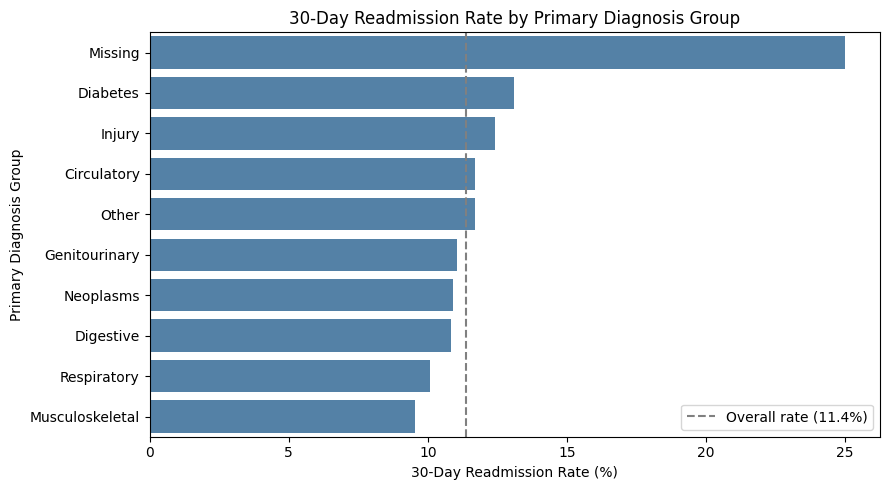

,encounters,readmission_rate
diag_1_group,,
Missing,20,25.00
Diabetes,8661,13.10
Injury,6851,12.41
Circulatory,29680,11.69
Other,17793,11.68
Genitourinary,5002,11.04
Neoplasms,3131,10.89
Digestive,9333,10.82
Respiratory,13934,10.06


In [30]:
# 30-day readmission rate by primary diagnosis group
diag_summary = (model_df.groupby("diag_1_group")[TARGET]
                .agg(encounters="count", readmission_rate="mean")
                .assign(readmission_rate=lambda d: d["readmission_rate"] * 100)
                .sort_values("readmission_rate", ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(x=diag_summary["readmission_rate"], y=diag_summary.index, color="steelblue")
plt.axvline(model_df[TARGET].mean() * 100, color="gray", linestyle="--",
            label=f"Overall rate ({model_df[TARGET].mean() * 100:.1f}%)")
plt.title("30-Day Readmission Rate by Primary Diagnosis Group")
plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Primary Diagnosis Group")
plt.legend()
plt.tight_layout()
plt.show()

diag_summary.round(2)

### 11.7 Preprocessing Results

**Cohort:** Removing encounters that ended in death or discharge to hospice excluded **2,423 encounters**, and removing invalid gender values excluded **3** more. The final modeling cohort contains **99,340 encounters from 69,987 unique patients**. The 30-day readmission rate rose slightly, from 11.16% to **11.39% (11,314 encounters)**, because the excluded encounters could not be readmitted and had been counted in the negative class. This is why figures in this section differ slightly from the Week 3 exploratory results in Sections 4–8, which describe the full dataset.

**Predictors removed:** Thirteen predictors met a removal rule. `weight` was missing in 96.85% of encounters, and twelve diabetes medication variables (including `examide` and `citoglipton`, which had no variation at all) had a single value in at least 99.9% of encounters. `max_glu_serum` and `A1Cresult` were kept, because their `None` value means "not tested" rather than missing. `medical_specialty` (49% missing) and `payer_code` (40% missing) were also kept, with missing values coded as an explicit `Missing` category, since whether these were recorded may itself be informative.

**Features:** The modeling dataset contains **36 predictors: 11 numeric and 25 categorical.** The diagnosis grouping reduced over 700 codes per diagnosis column to 10 categories. Readmission rates differed across primary diagnosis groups, from **9.54%** for musculoskeletal conditions to **13.10%** for diabetes as the primary diagnosis, suggesting that the grouped diagnoses carry predictive information.

**Leakage review:** `discharge_disposition_id` is retained as a predictor because the discharge destination is known at the time of discharge, which is when a readmission risk prediction would be made. The original `readmitted` column was dropped once the binary target was created, so it cannot enter the model.

---

### Enhancement 2: Rule-Based Cohort Definition with an Automated Cohort Flow Table

**What was modified:** A `define_cohort()` function applies the cohort exclusion rules set in `PREPROCESSING_CONFIG` (death or hospice discharge, invalid gender, and an optional first-encounter-only rule) and automatically produces a cohort flow table showing the encounters removed, encounters and patients remaining, and the readmission rate after each step.

**Why it was implemented:** In Week 3, discharge disposition was identified as a potential source of bias, because patients who died or went to hospice cannot be readmitted. Excluding them is necessary for a valid outcome definition, and the effect of each exclusion should be transparent.

**How it improves the workflow:** Cohort decisions are documented and reproducible, and the flow table is generated automatically rather than counted by hand, which mirrors the participant flow reporting used in clinical research. The `first_encounter_only` setting lets the cohort be redefined for a sensitivity analysis by changing one value.

### Enhancement 3: Automated Removal of Low-Information Predictors (Conditional Logic)

**What was modified:** Instead of dropping a hand-typed list of columns, `remove_low_information_columns()` checks every predictor against two configurable rules (more than 90% missing, or one value covering at least 99.9% of encounters) and returns a table explaining why each column was removed. Identifier and outcome columns are protected from removal.

**Why it was implemented:** Week 3 identified constant and near-constant medication variables by inspection. A hard-coded list would have to be updated by hand whenever the data or cohort change, and would not transfer to another dataset.

**How it improves the workflow:** The rule applies the same criteria to every column, documents each decision, and adapts automatically if the cohort definition changes or the pipeline is applied to another compatible dataset.

### Enhancement 4: Clinical Feature Engineering

**What was modified:** `engineer_features()` adds new features and recodes existing ones:

- **Diagnosis groups:** maps the ICD-9 codes in `diag_1`–`diag_3` to 10 clinical categories, following Strack et al. (2014), the original publication for this dataset.
- **Age:** converts age bands to an ordered numeric variable (`age_years`).
- **Total prior visits:** adds `total_prior_visits` (outpatient + emergency + inpatient visits in the prior year).
- **Medication changes:** adds `n_medication_changes` (the number of diabetes medications whose dose changed).
- **Medical specialty:** groups uncommon medical specialties as `Other`.
- **Coded IDs:** converts the integer-coded admission and discharge IDs to categories.

**Why it was implemented:** The diagnosis variables contained more than 700 distinct codes each. One-hot encoding them directly would have created thousands of sparse columns. Age was stored as text, and prior utilization, the strongest unadjusted predictor in Week 3, was split across three separate counts.

**How it improves the workflow:** The new features are clinically interpretable, greatly reduce the dimensionality of the feature space, and summarize information (overall utilization and treatment intensity) that individual variables capture only partially. All transformations are applied by a single function, so they are applied identically every time the pipeline runs.

**Reference:** Strack B, DeShazo JP, Gennings C, et al. Impact of HbA1c measurement on hospital readmission rates: analysis of 70,000 clinical database patient records. *BioMed Research International.* 2014;2014:781670.

## 12. Inferential Statistical Analysis

The exploratory analysis in Section 7 suggested that prior inpatient utilization was strongly associated with 30-day readmission. This section tests that association formally, and then tests every predictor in the modeling dataset against the outcome.

**Choice of tests:**

- **Categorical predictors vs. the binary outcome:** chi-square test of independence. Its assumption is an expected count of at least 5 in every cell, which is checked and reported.
- **Numeric predictors vs. the binary outcome:** Mann–Whitney U test. Most numeric predictors are counts that are heavily right-skewed (Section 12.3). The Mann–Whitney U test compares the two groups' distributions without assuming normality, so it is more appropriate here than an independent-samples t-test.

**Effect sizes:** With nearly 100,000 encounters, even very small differences produce p-values far below 0.05. Each test therefore also reports an effect size, which describes how strong the association is:

- **Cramér's V** for chi-square tests.
- **Rank-biserial correlation** for Mann–Whitney U tests.

Both are interpreted using common conventions: below 0.10 is negligible, 0.10–0.29 small, 0.30–0.49 medium, and 0.50 or above large.

The significance level is α = 0.05.

In [31]:
# Statistical testing libraries
from scipy import stats
from statsmodels.stats.multitest import multipletests

### 12.1 Statistical Testing Functions

In [32]:
def format_p(p, prefix=False):
    """Report very small p-values as '< 0.001' instead of 0 or scientific notation.
    With prefix=True, returns 'p < 0.001' or 'p = 0.042' for use in sentences."""
    text = "< 0.001" if p < 0.001 else f"{p:.3f}"
    if prefix:
        return "p " + text if p < 0.001 else "p = " + text
    return text


def chi_square_test(df, feature, target, warn=True):
    """Chi-square test of independence between a categorical feature and a
    binary target. Returns test results, Cramer's V, and the contingency table."""
    table = pd.crosstab(df[feature], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Assumption check: expected count of at least 5 in every cell
    min_expected = expected.min()
    if warn and min_expected < 5:
        print(f"  Note: '{feature}' has expected counts below 5 "
              f"(min = {min_expected:.2f}); interpret its chi-square result with caution.")

    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return {
        "Variable": feature, "Test": "Chi-square",
        "Statistic": chi2, "df": dof, "p-value": p,
        "Effect size": cramers_v, "Effect size measure": "Cramer's V",
        "Min expected count": min_expected,
        "Expected counts >= 5": "Yes" if min_expected >= 5 else "No",
    }, table


def mann_whitney_test(df, feature, target):
    """Mann-Whitney U test comparing a numeric feature between outcome groups.
    Returns test results, group medians, and the rank-biserial correlation."""
    group0 = df.loc[df[target] == 0, feature]
    group1 = df.loc[df[target] == 1, feature]
    u_stat, p = stats.mannwhitneyu(group1, group0, alternative="two-sided")

    # Rank-biserial correlation: positive = higher values in the readmitted group
    rank_biserial = 2 * u_stat / (len(group0) * len(group1)) - 1
    return {
        "Variable": feature, "Test": "Mann-Whitney U",
        "Statistic": u_stat, "df": np.nan, "p-value": p,
        "Effect size": rank_biserial, "Effect size measure": "Rank-biserial r",
        "Median (not readmitted)": group0.median(),
        "Median (readmitted)": group1.median(),
        "Expected counts >= 5": "n/a",
    }


def interpret_effect(value, measure):
    """Label effect size magnitude using common conventions (Cohen, 1988)."""
    # The same cutoffs apply to Cramer's V for a two-column table and to
    # the rank-biserial correlation.
    size = abs(value)
    cutoffs = (0.10, 0.30, 0.50)
    if size < cutoffs[0]:
        return "Negligible"
    if size < cutoffs[1]:
        return "Small"
    if size < cutoffs[2]:
        return "Medium"
    return "Large"

### 12.2 Primary Hypothesis: Prior Inpatient Admissions and 30-Day Readmission

- **H₀:** 30-day readmission is independent of the number of prior inpatient admissions.
- **H₁:** 30-day readmission rates differ across prior inpatient admission groups (0, 1, 2, 3+).

In [33]:
# =============================================================================
# PRIMARY TEST: Prior inpatient admissions vs. 30-day readmission
# H0: 30-day readmission is independent of prior inpatient admission group
# H1: 30-day readmission rates differ across prior inpatient admission groups
# =============================================================================
ALPHA = 0.05

stats_df = model_df.copy()
stats_df["prior_inpatient_group"] = pd.cut(
    stats_df["number_inpatient"], bins=[-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3+"]
)

primary_result, primary_table = chi_square_test(stats_df, "prior_inpatient_group", TARGET)

# Readmission rate in each group
primary_summary = primary_table.copy()
primary_summary.columns = ["Not readmitted", "Readmitted"]
primary_summary["Total"] = primary_summary.sum(axis=1)
primary_summary["Readmission rate (%)"] = (primary_summary["Readmitted"]
                                           / primary_summary["Total"] * 100).round(2)
display(primary_summary)

print(f"\nChi-square test of independence")
print(f"  chi2({primary_result['df']}) = {primary_result['Statistic']:.2f}")
print(f"  {format_p(primary_result['p-value'], prefix=True)}")
print(f"  Cramer's V = {primary_result['Effect size']:.3f} "
      f"({interpret_effect(primary_result['Effect size'], 'Cramer\'s V').lower()} effect)")
print(f"  Smallest expected cell count = {primary_result['Min expected count']:.0f} "
      f"(assumption of >= 5 {'met' if primary_result['Min expected count'] >= 5 else 'NOT met'})")
print()
if primary_result["p-value"] < ALPHA:
    print("  Reject H0: 30-day readmission rates differ across prior inpatient groups.")
else:
    print("  Fail to reject H0: no evidence that readmission rates differ across groups.")

,Not readmitted,Readmitted,Total,Readmission rate (%)
prior_inpatient_group,,,,
0,60552,5690,66242,8.59
1,16468,2516,18984,13.25
2,5991,1309,7300,17.93
3+,5015,1799,6814,26.40



Chi-square test of independence
  chi2(3) = 2411.04
  p < 0.001
  Cramer's V = 0.156 (small effect)
  Smallest expected cell count = 776 (assumption of >= 5 met)

  Reject H0: 30-day readmission rates differ across prior inpatient groups.


In [34]:
# Sensitivity analysis: the chi-square test assumes independent observations,
# but some patients contribute several encounters. Repeat the test using only
# each patient's first encounter, so every patient is counted once.
first_encounters = (stats_df.sort_values("encounter_id")
                            .drop_duplicates(subset="patient_nbr", keep="first"))

sens_result, sens_table = chi_square_test(first_encounters, "prior_inpatient_group", TARGET)
sens_rates = (sens_table[1] / sens_table.sum(axis=1) * 100).round(2)

print(f"First encounter per patient only: n = {len(first_encounters):,} patients")
print(f"  Readmission rate by group (%): {sens_rates.to_dict()}")
print(f"  chi2({sens_result['df']}) = {sens_result['Statistic']:.2f}, "
      f"{format_p(sens_result['p-value'], prefix=True)}, Cramer's V = {sens_result['Effect size']:.3f}")

First encounter per patient only: n = 69,987 patients
  Readmission rate by group (%): {'0': 8.13, '1': 12.88, '2': 18.52, '3+': 26.45}
  chi2(3) = 664.62, p < 0.001, Cramer's V = 0.097


#### Interpretation

The chi-square test confirmed the pattern seen in Section 7: 30-day readmission was **not independent of prior inpatient utilization** (χ²(3) = 2411.04, p < 0.001). Readmission rates rose steadily from **8.59%** among encounters with no prior inpatient admissions to **13.25%**, **17.93%**, and **26.40%** among those with one, two, and three or more. The smallest expected cell count was 776, so the test's assumption was met.

The effect size was **small (Cramér's V = 0.156)**. Prior inpatient utilization is clearly and consistently related to readmission, but on its own it explains only part of the variation in the outcome. This supports using multiple predictors together in a multivariable model.

**Sensitivity analysis:** The chi-square test assumes independent observations, but some patients contribute more than one encounter. When the test was repeated using only each patient's first encounter (69,987 patients), the same gradient was observed (8.13%, 12.88%, 18.52%, and 26.45%), and the association remained significant (χ²(3) = 664.62, p < 0.001, Cramér's V = 0.097). The finding is therefore not explained by repeated encounters from the same patients. The somewhat smaller effect size in this analysis reflects the fact that patients with many admissions contribute repeated high-risk encounters to the full cohort.

### 12.3 Distribution of Numeric Predictors

Before comparing numeric predictors between outcome groups, their distributions were examined to choose an appropriate test.

,Skewness
number_emergency,22.85
number_outpatient,8.84
total_prior_visits,5.35
number_inpatient,3.63
n_medication_changes,1.43
num_medications,1.34
num_procedures,1.32
time_in_hospital,1.14
num_lab_procedures,-0.24
age_years,-0.62


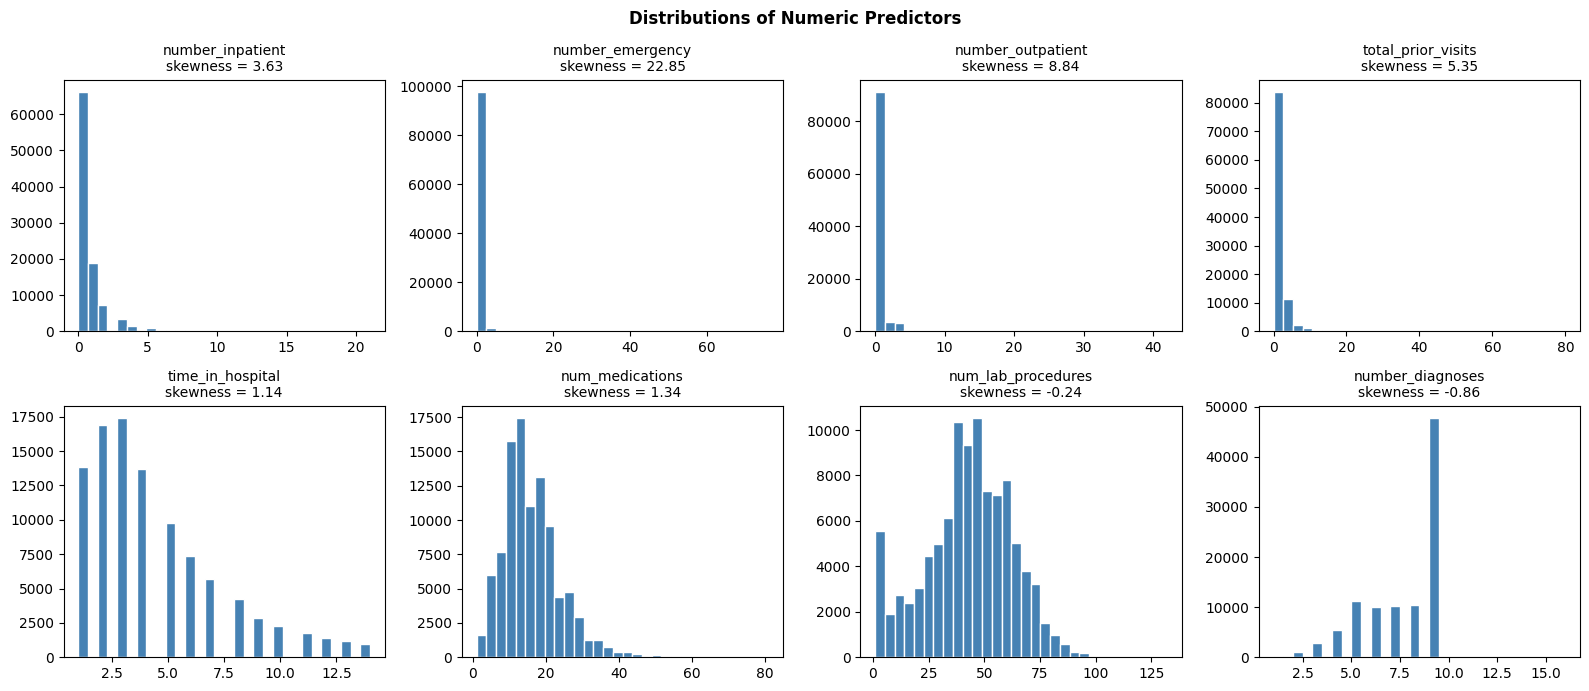

In [35]:
# =============================================================================
# CHOOSING A TEST FOR THE NUMERIC VARIABLES: check the distributions
# A t-test compares means and assumes approximately normal data. Formal
# normality tests (e.g., Shapiro-Wilk) reject normality for almost any
# deviation when n is this large, so skewness and histograms are used instead.
# =============================================================================
skewness = (model_df[NUMERIC_FEATURES].skew()
            .round(2).sort_values(ascending=False).rename("Skewness"))
display(skewness.to_frame())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, ["number_inpatient", "number_emergency", "number_outpatient",
                               "total_prior_visits", "time_in_hospital", "num_medications",
                               "num_lab_procedures", "number_diagnoses"]):
    ax.hist(model_df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}\nskewness = {model_df[col].skew():.2f}", fontsize=10)
plt.suptitle("Distributions of Numeric Predictors", fontweight="bold")
plt.tight_layout()
plt.show()

The prior-utilization variables are extremely right-skewed: most encounters have a value of 0, with a long tail of high values. `number_emergency` has a skewness of 22.85, `number_outpatient` 8.84, and `number_inpatient` 3.63. Several other count variables are also moderately skewed. Because the normality assumption of the t-test is not reasonable for these variables, the **Mann–Whitney U test** was used for all numeric predictors, so the same test is applied consistently to every one of them.

### 12.4 Automated Testing of All Predictors

Every predictor in the modeling dataset is tested against 30-day readmission using the appropriate test. Because 36 tests are performed, the chance of at least one false-positive result is much higher than 5%. P-values are therefore adjusted using the **Holm method**, which controls the family-wise error rate and is less conservative than a Bonferroni correction. Results are sorted by effect size rather than p-value, because effect size is more informative at this sample size.

In [36]:
# =============================================================================
# AUTOMATED TESTING OF ALL PREDICTORS
# Each predictor is tested against the outcome with the appropriate test:
#   numeric      -> Mann-Whitney U (skewed count data)
#   categorical  -> chi-square test of independence
# Because ~36 tests are run, p-values are adjusted with the Holm method to
# control the chance of any false-positive finding.
# =============================================================================
def run_univariate_tests(df, numeric_features, categorical_features, target, alpha=0.05):
    """Test every predictor against a binary target and return one summary table."""
    results = [mann_whitney_test(df, col, target) for col in numeric_features]
    results += [chi_square_test(df, col, target, warn=False)[0] for col in categorical_features]

    summary = pd.DataFrame(results)
    summary["Holm-adjusted p"] = multipletests(summary["p-value"], method="holm")[1]
    summary["Significant"] = np.where(summary["Holm-adjusted p"] < alpha, "Yes", "No")
    summary["Effect magnitude"] = [interpret_effect(v, m) for v, m in
                                   zip(summary["Effect size"], summary["Effect size measure"])]
    return summary.sort_values("Effect size", key=abs, ascending=False).reset_index(drop=True)


test_summary = run_univariate_tests(model_df, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET, ALPHA)

# Readable display version of the results
display_table = test_summary.assign(
    **{"Effect size": test_summary["Effect size"].round(3),
       "Holm-adjusted p": test_summary["Holm-adjusted p"].apply(format_p),
       # medians apply only to numeric predictors; leave blank for categorical
       "Median (not readmitted)": test_summary["Median (not readmitted)"].astype(object).fillna(""),
       "Median (readmitted)": test_summary["Median (readmitted)"].astype(object).fillna("")}
)[["Variable", "Test", "Median (not readmitted)", "Median (readmitted)",
   "Effect size", "Effect size measure", "Effect magnitude",
   "Holm-adjusted p", "Significant", "Expected counts >= 5"]]
display(display_table)

n_sig = (test_summary["Significant"] == "Yes").sum()
n_sparse = (test_summary["Expected counts >= 5"] == "No").sum()
print(f"\n{n_sig} of {len(test_summary)} predictors were significantly associated with "
      f"30-day readmission after Holm correction.")
print(f"{n_sparse} categorical predictor(s) have rare categories with expected counts below 5; "
      f"their chi-square p-values are approximate.")

,Variable,Test,Median (not readmitted),Median (readmitted),Effect size,Effect size measure,Effect magnitude,Holm-adjusted p,Significant,Expected counts >= 5
0,number_inpatient,Mann-Whitney U,0.0,0.0,0.215,Rank-biserial r,Small,< 0.001,Yes,n/a
1,total_prior_visits,Mann-Whitney U,0.0,1.0,0.208,Rank-biserial r,Small,< 0.001,Yes,n/a
2,discharge_disposition_id,Chi-square,,,0.115,Cramer's V,Small,< 0.001,Yes,No
3,time_in_hospital,Mann-Whitney U,4.0,4.0,0.095,Rank-biserial r,Negligible,< 0.001,Yes,n/a
4,number_diagnoses,Mann-Whitney U,8.0,9.0,0.088,Rank-biserial r,Negligible,< 0.001,Yes,n/a
5,num_medications,Mann-Whitney U,15.0,16.0,0.087,Rank-biserial r,Negligible,< 0.001,Yes,n/a
6,number_emergency,Mann-Whitney U,0.0,0.0,0.064,Rank-biserial r,Negligible,< 0.001,Yes,n/a
7,n_medication_changes,Mann-Whitney U,0.0,0.0,0.053,Rank-biserial r,Negligible,< 0.001,Yes,n/a
8,insulin,Chi-square,,,0.045,Cramer's V,Negligible,< 0.001,Yes,Yes
9,num_lab_procedures,Mann-Whitney U,44.0,45.0,0.044,Rank-biserial r,Negligible,< 0.001,Yes,n/a



25 of 36 predictors were significantly associated with 30-day readmission after Holm correction.
9 categorical predictor(s) have rare categories with expected counts below 5; their chi-square p-values are approximate.


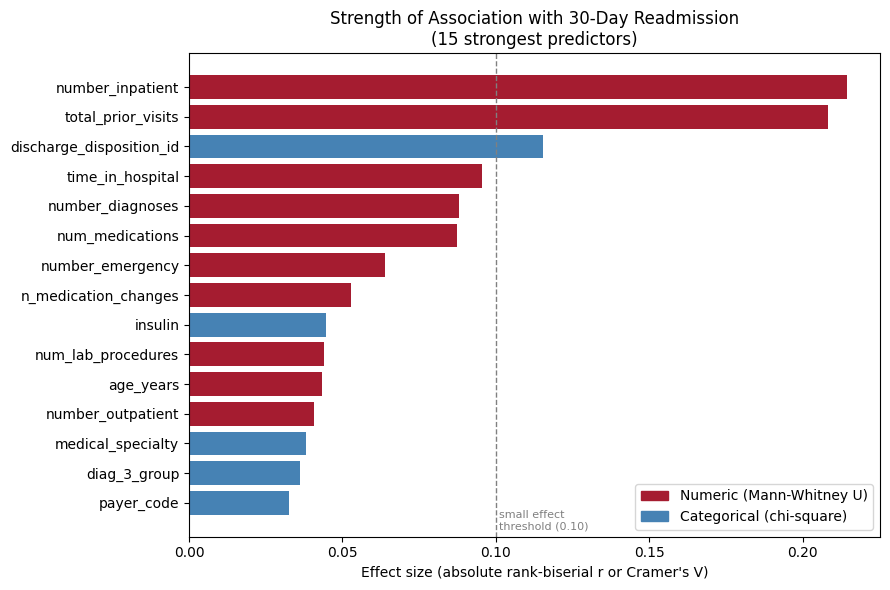

In [37]:
# Effect sizes for the predictors with the strongest associations
top = test_summary.head(15).iloc[::-1]
colors = ["#A51C30" if t == "Mann-Whitney U" else "steelblue" for t in top["Test"]]

plt.figure(figsize=(9, 6))
plt.barh(top["Variable"], top["Effect size"].abs(), color=colors)
plt.axvline(0.10, color="gray", linestyle="--", linewidth=1)
plt.text(0.101, -0.9, "small effect\nthreshold (0.10)", fontsize=8, color="gray")
plt.xlabel("Effect size (absolute rank-biserial r or Cramer's V)")
plt.title("Strength of Association with 30-Day Readmission\n(15 strongest predictors)")
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color="#A51C30", label="Numeric (Mann-Whitney U)"),
                    Patch(color="steelblue", label="Categorical (chi-square)")],
           loc="lower right")
plt.tight_layout()
plt.show()

#### Interpretation

After Holm correction, **25 of 36 predictors** were significantly associated with 30-day readmission. However, the effect sizes show that statistical significance largely reflects the very large sample:

- **Only three predictors had a small effect:**
  - prior inpatient admissions (`number_inpatient`, rank-biserial r = 0.215)
  - total prior visits (`total_prior_visits`, r = 0.208, an engineered feature from Section 11)
  - discharge disposition (`discharge_disposition_id`, Cramér's V = 0.115)
- **All other significant predictors had negligible effects (below 0.10).** These include length of stay, number of diagnoses, number of medications, and insulin use. Readmitted encounters had slightly higher median numbers of diagnoses (9 vs. 8) and medications (16 vs. 15).
- **Not significant:** gender, number of procedures, and most individual oral diabetes medications (for example, glipizide, glyburide, and pioglitazone).

Nine categorical predictors contain rare categories with expected counts below 5, so their chi-square p-values are approximate. None of these predictors had more than a small effect, and their categories are kept for modeling.

**Implications for modeling:** No single predictor is strongly associated with 30-day readmission. Prior healthcare utilization is the most informative domain. Because the individual associations are weak, predictive performance will depend on combining many predictors, and the models in the next section are expected to achieve only modest discrimination. This is consistent with published readmission models, which typically report modest performance.

---

### Enhancement 5: Automated Statistical Testing Framework

**What was modified:** Reusable functions were written for the chi-square test (`chi_square_test()`) and the Mann–Whitney U test (`mann_whitney_test()`). Each one returns the test statistic, the p-value, an effect size, and an assumption check. `run_univariate_tests()` then automatically applies the appropriate test to every predictor based on its data type, adjusts all p-values for multiple comparisons using the Holm method, labels effect size magnitude, and returns a single summary table and plot. A sensitivity analysis repeats the primary test using one encounter per patient.

**Why it was implemented:** The course templates test one hand-picked variable at a time. Running many tests that way would be repetitive, and it would not account for multiple comparisons. At this sample size, p-values alone are also misleading, because nearly every comparison is significant.

**How it improves the workflow:**

- **Consistent and documented:** the same rules for choosing a test and checking its assumptions are applied to every predictor.
- **Honest about multiple testing:** false-positive findings are controlled when many tests are run.
- **Focused on meaningful associations:** sorting by effect size shows which associations are clinically meaningful, not just statistically significant.
- **Automatic:** the analysis updates automatically if the cohort or the feature set changes.

## 13. Supervised Machine Learning

This section trains and compares five supervised classification models to predict 30-day readmission:

| Model | Type | Why it was included |
|---|---|---|
| Logistic Regression | Linear | Interpretable baseline that is widely used in clinical risk prediction |
| Decision Tree | Tree-based | Simple, rule-based model that captures non-linear relationships |
| Random Forest | Ensemble (bagging) | Averages many decorrelated trees to reduce variance |
| XGBoost | Ensemble (boosting) | Builds trees sequentially to correct earlier errors; strong on tabular data |
| Neural Network (MLP) | Multi-layer perceptron | Learns non-linear combinations of predictors through hidden layers |

A support vector machine was considered but not included, because training time for kernel SVMs grows rapidly with sample size and is impractical with about 70,000 training encounters.

**Workflow:**

1. Split the data by patient into training, validation, and test sets.
2. Build one preprocessing pipeline that is fitted on the training data only.
3. Tune selected models on the validation set.
4. Train all five models.
5. Choose each model's decision threshold on the validation set.
6. Evaluate every model once on the untouched test set.

**F1 score is the primary metric**, as proposed in Section 10. Precision, recall, specificity, accuracy, AUROC, and PR-AUC are reported as secondary metrics.

In [38]:
# Machine learning libraries
import time
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (f1_score, precision_score, recall_score, accuracy_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42

### 13.1 Patient-Level Train / Validation / Test Split

The data are split into **70% training, 15% validation, and 15% test**:

- **Training set:** used to fit the models.
- **Validation set:** used to tune settings and choose decision thresholds.
- **Test set:** held out until final evaluation.

The split is made **by patient** (`patient_nbr`) rather than by encounter. Because many patients have several encounters, a random split by encounter would put some patients in both the training and test sets. The model could then partly recognize patients it had already seen, which would overstate its performance on new patients. The split function confirms that no patient appears in more than one subset. The readmission rate is similar across all three subsets, so stratification was not needed.

In [39]:
# =============================================================================
# PATIENT-LEVEL TRAIN / VALIDATION / TEST SPLIT (70% / 15% / 15%)
# All encounters from the same patient are placed in the same subset, so the
# models are always evaluated on patients they have never seen.
# =============================================================================
def patient_level_split(df, group_col, train_size=0.70, val_size=0.15, random_state=42):
    """Split a dataframe into train, validation, and test sets by patient."""
    # Step 1: training patients vs. everyone else
    outer = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    train_idx, temp_idx = next(outer.split(df, groups=df[group_col]))
    train, temp = df.iloc[train_idx], df.iloc[temp_idx]

    # Step 2: divide the remaining patients evenly between validation and test
    val_share = val_size / (1 - train_size)
    inner = GroupShuffleSplit(n_splits=1, train_size=val_share, random_state=random_state)
    val_idx, test_idx = next(inner.split(temp, groups=temp[group_col]))
    val, test = temp.iloc[val_idx], temp.iloc[test_idx]

    # Validation: no patient may appear in more than one subset
    train_p, val_p, test_p = (set(s[group_col]) for s in (train, val, test))
    assert not (train_p & val_p or train_p & test_p or val_p & test_p), \
        "Patient overlap detected between subsets."
    assert len(train) + len(val) + len(test) == len(df), "Rows lost during splitting."
    return train, val, test


train_df, val_df, test_df = patient_level_split(model_df, "patient_nbr", random_state=RANDOM_STATE)

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

split_summary = pd.DataFrame({
    "Encounters": [len(train_df), len(val_df), len(test_df)],
    "Patients": [train_df["patient_nbr"].nunique(), val_df["patient_nbr"].nunique(),
                 test_df["patient_nbr"].nunique()],
    "Share of encounters (%)": [round(len(s) / len(model_df) * 100, 1)
                                for s in (train_df, val_df, test_df)],
    "30-day readmission rate (%)": [round(s[TARGET].mean() * 100, 2)
                                    for s in (train_df, val_df, test_df)],
}, index=["Training", "Validation", "Test"])
print("Patient-level split passed: no patient appears in more than one subset.")
split_summary

Patient-level split passed: no patient appears in more than one subset.


,Encounters,Patients,Share of encounters (%),30-day readmission rate (%)
Training,69613,48990,70.1,11.37
Validation,14868,10498,15.0,11.56
Test,14859,10499,15.0,11.31


### 13.2 Preprocessing Pipeline

Encoding and scaling are performed inside a scikit-learn `Pipeline`, so they are learned from the training data only and then applied unchanged to the validation and test data. This prevents data leakage.

- **Numeric predictors:** Yeo-Johnson power transformation followed by standardization (mean 0, SD 1). This reduces the strong right skew identified in Section 12.3, and it is required for logistic regression and the neural network, which are sensitive to the scale of their inputs.
- **Categorical predictors:** one-hot encoding. Categories seen in fewer than 20 training encounters are combined into a single "infrequent" category, which addresses the sparse categories identified in Section 12.4. Categories that appear only in the validation or test data are handled without error.

No imputation is needed, because missing categorical values were coded as an explicit `Missing` category in Section 11, and no numeric predictors have missing values.

In [40]:
# =============================================================================
# PREPROCESSING PIPELINE (fitted on the training data only)
#   Numeric features     -> Yeo-Johnson power transform + standardization
#                           (reduces skew; required for logistic regression and the MLP)
#   Categorical features -> one-hot encoding; categories seen in fewer than 20
#                           training encounters are grouped as "infrequent", and
#                           categories never seen in training are handled safely
# =============================================================================
def build_preprocessor(numeric_features, categorical_features, min_category_count=20):
    return ColumnTransformer(transformers=[
        ("num", PowerTransformer(method="yeo-johnson", standardize=True), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              min_frequency=min_category_count), categorical_features),
    ])


preprocessor = build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
n_encoded = preprocessor.fit(X_train).transform(X_train.head()).shape[1]
print(f"{len(FEATURES)} predictors -> {n_encoded} model inputs after one-hot encoding")

36 predictors -> 166 model inputs after one-hot encoding


### 13.3 Model Definitions

All five models are defined once in a `MODEL_REGISTRY` dictionary. Only 11% of encounters are readmissions, so models trained without adjustment tend to predict "not readmitted" for almost everyone. Class imbalance is handled in two ways:

- **Class weights:** logistic regression, the decision tree, and the random forest use `class_weight="balanced"`, and XGBoost uses `scale_pos_weight` (about 7.8). Errors on readmitted encounters therefore count more during training.
- **Decision-threshold tuning (Section 13.5):** this applies to all models. It is especially important for the neural network, because scikit-learn's `MLPClassifier` does not support class weights.

The neural network follows the architecture in the course materials:

- **Layers:** two hidden layers (64 and 32 neurons) with ReLU activation and a sigmoid output.
- **Training:** the Adam optimizer, with L2 regularization (`alpha`).
- **Early stopping:** training stops when the score on an internal 10% validation sample stops improving, to prevent overfitting.

In [41]:
# =============================================================================
# MODEL REGISTRY
# Each model is defined once here. Class imbalance (11% positive) is handled
# with class weights where the algorithm supports them; the MLP does not
# support class weights, so it relies on decision-threshold tuning (12.4).
# =============================================================================
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # ~7.8 negatives per positive

MODEL_REGISTRY = {
    "Logistic Regression": LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50, class_weight="balanced",
        random_state=RANDOM_STATE),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20, max_features="sqrt",
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),

    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=pos_weight, eval_metric="logloss",
        n_jobs=-1, random_state=RANDOM_STATE),

    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32),   # two hidden layers
        activation="relu", solver="adam",
        alpha=0.001,                   # L2 regularization
        batch_size=256, learning_rate_init=0.001, max_iter=200,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        random_state=RANDOM_STATE),
}

print(f"{len(MODEL_REGISTRY)} models registered: {list(MODEL_REGISTRY)}")
print(f"Positive-class weight for XGBoost: {pos_weight:.2f}")

5 models registered: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network (MLP)']
Positive-class weight for XGBoost: 7.80


### 13.4 Hyperparameter Tuning

The decision tree and XGBoost are tuned using a small grid of settings. Each combination is trained on the training set and scored on the validation set using **PR-AUC** (the area under the precision-recall curve). PR-AUC summarizes performance across all possible thresholds and focuses on the minority class, so it is a better guide for choosing settings than F1 at one fixed cutoff. A grid search with cross-validation was not used, because the separate validation set provides a large, patient-independent tuning sample at a fraction of the computation time. The other three models use standard settings chosen in advance.

In [42]:
# =============================================================================
# SHARED TRAINING AND EVALUATION FUNCTIONS
# =============================================================================
def find_best_threshold(y_true, y_prob):
    """Return the probability cutoff that maximizes F1 on the given data."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    best = np.argmax(f1[:-1])          # last precision/recall pair has no threshold
    return float(thresholds[best])


def compute_metrics(y_true, y_prob, threshold):
    """All evaluation metrics for one model at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUROC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Threshold": threshold,
    }


def train_and_evaluate(name, estimator, preprocessor, X_train, y_train, X_val, y_val, X_test, y_test):
    """Fit one model pipeline, tune its threshold on the validation set,
    and evaluate it on the training, validation, and test sets."""
    pipeline = Pipeline([("preprocess", clone(preprocessor)), ("model", estimator)])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_seconds = time.time() - start

    prob_train = pipeline.predict_proba(X_train)[:, 1]
    prob_val = pipeline.predict_proba(X_val)[:, 1]
    prob_test = pipeline.predict_proba(X_test)[:, 1]

    # Threshold chosen on validation data only; the test set is never used for tuning
    threshold = find_best_threshold(y_val, prob_val)

    results = {}
    for subset, y_true, prob in [("Train", y_train, prob_train),
                                 ("Validation", y_val, prob_val),
                                 ("Test", y_test, prob_test)]:
        results[subset] = compute_metrics(y_true, prob, threshold)
        results[subset]["Default-threshold F1 (0.5)"] = f1_score(y_true, (prob >= 0.5).astype(int))

    print(f"{name:<22} trained in {train_seconds:6.1f} s | threshold = {threshold:.3f} | "
          f"test F1 = {results['Test']['F1']:.3f} | test AUROC = {results['Test']['AUROC']:.3f}")
    return {"pipeline": pipeline, "threshold": threshold, "results": results,
            "test_probabilities": prob_test, "train_seconds": train_seconds}

In [43]:
# =============================================================================
# HYPERPARAMETER TUNING ON THE VALIDATION SET
# Each candidate setting is trained on the training set and scored on the
# validation set using PR-AUC, which summarizes performance across all
# thresholds and focuses on the minority class. The test set is not used.
# =============================================================================
def tune_on_validation(estimator, param_grid, preprocessor, X_train, y_train, X_val, y_val):
    """Try every combination in param_grid and return the best estimator and a results table."""
    X_train_enc = clone(preprocessor).fit(X_train)
    Xt, Xv = X_train_enc.transform(X_train), X_train_enc.transform(X_val)

    rows = []
    for params in ParameterGrid(param_grid):
        model = clone(estimator).set_params(**params).fit(Xt, y_train)
        rows.append({**params,
                     "Train PR-AUC": average_precision_score(y_train, model.predict_proba(Xt)[:, 1]),
                     "Validation PR-AUC": average_precision_score(y_val, model.predict_proba(Xv)[:, 1])})

    results = pd.DataFrame(rows).sort_values("Validation PR-AUC", ascending=False)
    best_params = {k: results.iloc[0][k] for k in param_grid}
    best_params = {k: (int(v) if float(v).is_integer() else float(v)) for k, v in best_params.items()}
    return clone(estimator).set_params(**best_params), best_params, results.round(4)


TUNING_GRIDS = {
    "Decision Tree": {"max_depth": [4, 6, 8, 10], "min_samples_leaf": [50, 200]},
    "XGBoost": {"max_depth": [3, 4, 5], "min_child_weight": [1, 10],
                "n_estimators": [300, 600]},
}

for name, grid in TUNING_GRIDS.items():
    tuned, best_params, tuning_results = tune_on_validation(
        MODEL_REGISTRY[name], grid, preprocessor, X_train, y_train, X_val, y_val)
    MODEL_REGISTRY[name] = tuned
    print(f"{name}: best settings {best_params}")
    display(tuning_results.head(5))

Decision Tree: best settings {'max_depth': 8, 'min_samples_leaf': 50}


,max_depth,min_samples_leaf,Train PR-AUC,Validation PR-AUC
4,8,50,0.2389,0.2060
2,6,50,0.2173,0.2056
6,10,50,0.2591,0.2038
3,6,200,0.2133,0.2006
5,8,200,0.2255,0.1972


XGBoost: best settings {'max_depth': 5, 'min_child_weight': 10, 'n_estimators': 600}


,max_depth,min_child_weight,n_estimators,Train PR-AUC,Validation PR-AUC
11,5,10,600,0.3866,0.2403
7,4,10,600,0.3182,0.2398
6,4,10,300,0.2812,0.2381
10,5,10,300,0.3230,0.2379
3,3,10,600,0.2704,0.2366


### 13.5 Training, Threshold Tuning, and Evaluation

By default, a classifier predicts "readmitted" when its predicted probability is at least 0.5. With an imbalanced outcome, 0.5 is rarely the best cutoff. For each model, the threshold that **maximizes F1 on the validation set** is selected, and the model is then evaluated once on the test set at that threshold. The test set is never used to choose the threshold or any other setting.

Training all five models takes about 2–5 minutes in Colab.

In [44]:
# =============================================================================
# TRAIN AND EVALUATE ALL MODELS
# (about 3-6 minutes in Colab; the random forest and neural network take longest)
# =============================================================================
model_outputs = {}
for name, estimator in MODEL_REGISTRY.items():
    model_outputs[name] = train_and_evaluate(
        name, estimator, preprocessor, X_train, y_train, X_val, y_val, X_test, y_test
    )

mlp = model_outputs["Neural Network (MLP)"]["pipeline"].named_steps["model"]
print(f"\nNeural network stopped early after {mlp.n_iter_} epochs "
      f"(best internal validation score {mlp.best_validation_score_:.3f}).")

Logistic Regression    trained in    4.7 s | threshold = 0.521 | test F1 = 0.276 | test AUROC = 0.665
Decision Tree          trained in    4.0 s | threshold = 0.562 | test F1 = 0.278 | test AUROC = 0.653
Random Forest          trained in   70.6 s | threshold = 0.549 | test F1 = 0.287 | test AUROC = 0.679
XGBoost                trained in    7.3 s | threshold = 0.547 | test F1 = 0.290 | test AUROC = 0.681
Neural Network (MLP)   trained in   19.8 s | threshold = 0.143 | test F1 = 0.272 | test AUROC = 0.663

Neural network stopped early after 19 epochs (best internal validation score 0.887).


### 13.6 Model Comparison

The table below reports test-set performance for each model, ranked by F1. A reference row shows the result of predicting "readmitted" for every encounter, which is the F1 any useful model must exceed.

In [45]:
# =============================================================================
# MODEL COMPARISON ON THE HELD-OUT TEST SET (ranked by F1, the primary metric)
# =============================================================================
comparison = pd.DataFrame({name: out["results"]["Test"] for name, out in model_outputs.items()}).T
comparison = comparison.sort_values("F1", ascending=False)

# Reference point: a "model" that predicts readmission for every encounter
prevalence = y_test.mean()
baseline = pd.DataFrame([{
    "F1": 2 * prevalence / (1 + prevalence), "Precision": prevalence,
    "Recall (Sensitivity)": 1.0, "Specificity": 0.0, "Accuracy": prevalence,
    "AUROC": 0.5, "PR-AUC": prevalence, "Threshold": np.nan,
    "Default-threshold F1 (0.5)": np.nan,
}], index=["Reference: predict all readmitted"])

comparison_table = pd.concat([comparison, baseline]).round(3)
display(comparison_table)

BEST_MODEL = comparison.index[0]
print(f"\nBest model by test F1: {BEST_MODEL} (F1 = {comparison.loc[BEST_MODEL, 'F1']:.3f})")

,F1,Precision,Recall (Sensitivity),Specificity,Accuracy,AUROC,PR-AUC,Threshold,Default-threshold F1 (0.5)
XGBoost,0.290,0.219,0.427,0.806,0.763,0.681,0.243,0.547,0.286
Random Forest,0.287,0.238,0.363,0.852,0.796,0.679,0.218,0.549,0.287
Decision Tree,0.278,0.206,0.424,0.792,0.750,0.653,0.206,0.562,0.266
Logistic Regression,0.276,0.183,0.558,0.683,0.669,0.665,0.194,0.521,0.275
Neural Network (MLP),0.272,0.188,0.495,0.727,0.701,0.663,0.210,0.143,0.014
Reference: predict all readmitted,0.203,0.113,1.000,0.000,0.113,0.500,0.113,NaN,NaN



Best model by test F1: XGBoost (F1 = 0.290)


### 13.7 Confidence Intervals for Test Performance

The test F1 scores are close together. To judge whether the differences are meaningful, 95% confidence intervals were estimated with a **patient-level bootstrap**. Test-set patients are resampled with replacement 500 times, and F1 and AUROC are recalculated each time.

In [46]:
# =============================================================================
# 95% CONFIDENCE INTERVALS FOR TEST PERFORMANCE (patient-level bootstrap)
# The F1 scores are close together, so confidence intervals show whether the
# differences between models are larger than chance variation. Patients (not
# encounters) are resampled, so repeat encounters stay together.
# =============================================================================
def bootstrap_ci(y_true, y_prob, threshold, groups, n_boot=500, random_state=42):
    """Patient-level bootstrap 95% CIs for test-set F1 and AUROC."""
    rng = np.random.default_rng(random_state)
    y_true, y_prob, groups = np.asarray(y_true), np.asarray(y_prob), np.asarray(groups)
    patients = np.unique(groups)
    rows_by_patient = pd.Series(np.arange(len(groups))).groupby(groups).apply(np.array)

    f1s, aucs = [], []
    for _ in range(n_boot):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate(rows_by_patient.loc[sampled].values)
        y_b, p_b = y_true[idx], y_prob[idx]
        f1s.append(f1_score(y_b, (p_b >= threshold).astype(int)))
        aucs.append(roc_auc_score(y_b, p_b))
    return np.percentile(f1s, [2.5, 97.5]), np.percentile(aucs, [2.5, 97.5])


ci_rows = []
for name in comparison.index:
    out = model_outputs[name]
    f1_ci, auc_ci = bootstrap_ci(y_test, out["test_probabilities"], out["threshold"],
                                 test_df["patient_nbr"], random_state=RANDOM_STATE)
    ci_rows.append({"Model": name,
                    "Test F1 (95% CI)": f"{out['results']['Test']['F1']:.3f} ({f1_ci[0]:.3f}-{f1_ci[1]:.3f})",
                    "Test AUROC (95% CI)": f"{out['results']['Test']['AUROC']:.3f} ({auc_ci[0]:.3f}-{auc_ci[1]:.3f})"})

pd.DataFrame(ci_rows).set_index("Model")

,Test F1 (95% CI),Test AUROC (95% CI)
Model,,
XGBoost,0.290 (0.268-0.312),0.681 (0.664-0.697)
Random Forest,0.287 (0.263-0.313),0.679 (0.661-0.695)
Decision Tree,0.278 (0.256-0.301),0.653 (0.637-0.671)
Logistic Regression,0.276 (0.259-0.293),0.665 (0.649-0.679)
Neural Network (MLP),0.272 (0.255-0.289),0.663 (0.648-0.678)


### 13.8 Generalization and Overfitting Check

Comparing performance on the training, validation, and test sets shows whether a model has memorized the training data. The table also compares test F1 at the tuned threshold with test F1 at the default 0.5 threshold.

In [47]:
# Generalization check: compare performance on training, validation, and test data.
# A large drop from training to test indicates overfitting.
generalization = pd.DataFrame({
    name: {"Train AUROC": out["results"]["Train"]["AUROC"],
           "Validation AUROC": out["results"]["Validation"]["AUROC"],
           "Test AUROC": out["results"]["Test"]["AUROC"],
           "Train-Test AUROC gap": out["results"]["Train"]["AUROC"] - out["results"]["Test"]["AUROC"],
           "Test F1 (tuned threshold)": out["results"]["Test"]["F1"],
           "Test F1 (default 0.5)": out["results"]["Test"]["Default-threshold F1 (0.5)"]}
    for name, out in model_outputs.items()
}).T.round(3)
generalization

,Train AUROC,Validation AUROC,Test AUROC,Train-Test AUROC gap,Test F1 (tuned threshold),Test F1 (default 0.5)
Logistic Regression,0.666,0.663,0.665,0.001,0.276,0.275
Decision Tree,0.685,0.647,0.653,0.031,0.278,0.266
Random Forest,0.746,0.670,0.679,0.068,0.287,0.287
XGBoost,0.805,0.672,0.681,0.124,0.290,0.286
Neural Network (MLP),0.719,0.662,0.663,0.056,0.272,0.014


### 13.9 Model Comparison Plots

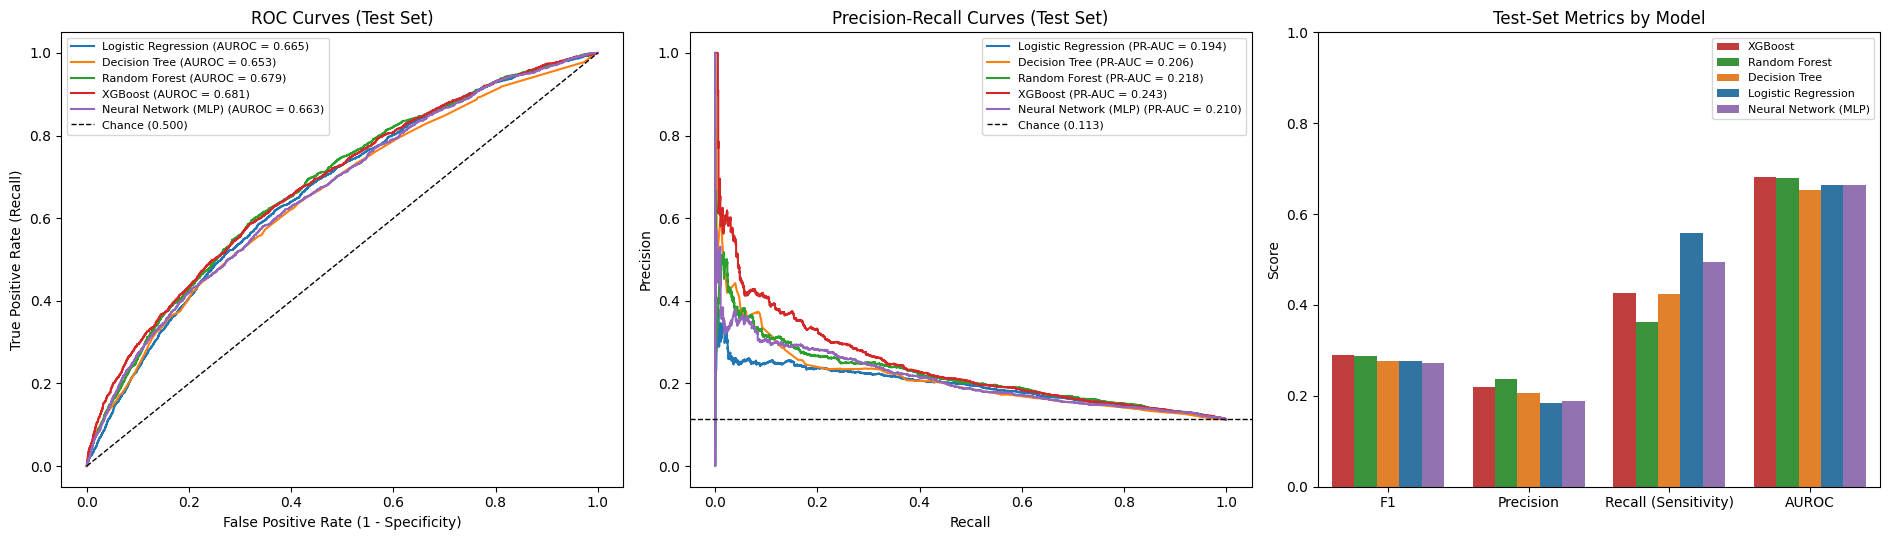

In [48]:
# =============================================================================
# MODEL COMPARISON PLOTS: ROC curves, precision-recall curves, and metrics
# =============================================================================
palette = dict(zip(model_outputs, sns.color_palette("tab10", len(model_outputs))))
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for name, out in model_outputs.items():
    prob = out["test_probabilities"]
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=palette[name],
                 label=f"{name} (AUROC = {out['results']['Test']['AUROC']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, color=palette[name],
                 label=f"{name} (PR-AUC = {out['results']['Test']['PR-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance (0.500)")
axes[0].set(xlabel="False Positive Rate (1 - Specificity)", ylabel="True Positive Rate (Recall)",
            title="ROC Curves (Test Set)")
axes[1].axhline(prevalence, color="k", linestyle="--", linewidth=1,
                label=f"Chance ({prevalence:.3f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves (Test Set)")
for ax in axes[:2]:
    ax.legend(fontsize=8, loc="best")

metric_plot = (comparison[["F1", "Precision", "Recall (Sensitivity)", "AUROC"]]
               .reset_index().melt(id_vars="index", var_name="Metric", value_name="Score"))
sns.barplot(data=metric_plot, x="Metric", y="Score", hue="index", palette=palette, ax=axes[2])
axes[2].set(title="Test-Set Metrics by Model", xlabel="", ylim=(0, 1))
axes[2].legend(title="", fontsize=8)

plt.tight_layout()
plt.show()

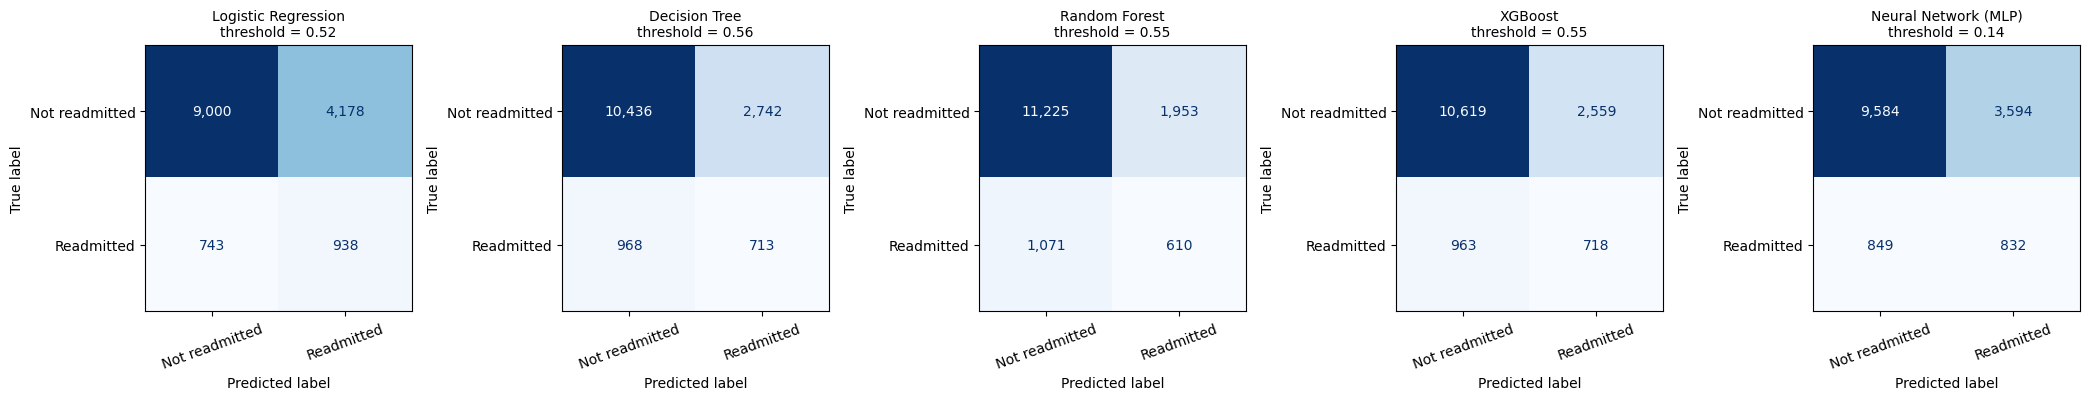

In [49]:
# Confusion matrices on the test set (at each model's tuned threshold)
fig, axes = plt.subplots(1, len(model_outputs), figsize=(4.2 * len(model_outputs), 4))
for ax, (name, out) in zip(axes, model_outputs.items()):
    y_pred = (out["test_probabilities"] >= out["threshold"]).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=["Not readmitted", "Readmitted"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(f"{name}\nthreshold = {out['threshold']:.2f}", fontsize=10)
    ax.tick_params(axis="x", labelrotation=20)
plt.tight_layout()
plt.show()

### 13.10 Feature Importance

Permutation importance measures how much the best model's PR-AUC drops when each predictor is randomly shuffled in the validation data. It is calculated on the original 36 predictors, not on the one-hot encoded columns, so each categorical variable is assessed as a whole, and the same method works for any model type.

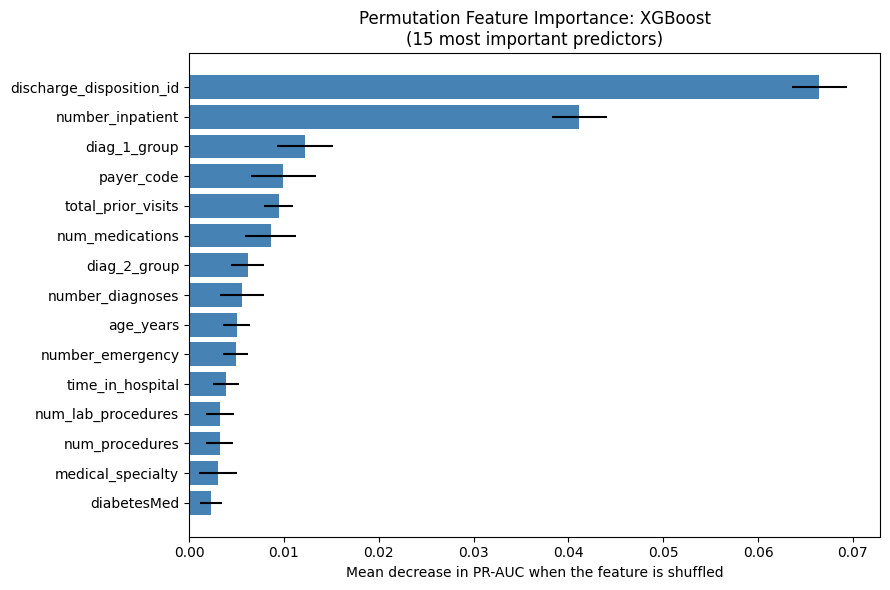

,Feature,Importance (drop in PR-AUC),SD
0,discharge_disposition_id,0.0665,0.0029
1,number_inpatient,0.0411,0.0029
2,diag_1_group,0.0122,0.0029
3,payer_code,0.0099,0.0034
4,total_prior_visits,0.0094,0.0015
5,num_medications,0.0086,0.0027
6,diag_2_group,0.0062,0.0017
7,number_diagnoses,0.0056,0.0023
8,age_years,0.0050,0.0014
9,number_emergency,0.0049,0.0013


In [50]:
# =============================================================================
# FEATURE IMPORTANCE FOR THE BEST MODEL (permutation importance)
# Each predictor is randomly shuffled in the validation data and the drop in
# PR-AUC is measured. Larger drops mean the model relies more on that predictor.
# This works for any model type, including the neural network.
# =============================================================================
best_pipeline = model_outputs[BEST_MODEL]["pipeline"]
sample = X_val.sample(n=min(8000, len(X_val)), random_state=RANDOM_STATE)

perm = permutation_importance(best_pipeline, sample, y_val.loc[sample.index],
                              scoring="average_precision", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)

importance = (pd.DataFrame({"Feature": FEATURES,
                            "Importance (drop in PR-AUC)": perm.importances_mean,
                            "SD": perm.importances_std})
              .sort_values("Importance (drop in PR-AUC)", ascending=False)
              .reset_index(drop=True))

top15 = importance.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top15["Feature"], top15["Importance (drop in PR-AUC)"], xerr=top15["SD"],
         color="steelblue")
plt.xlabel("Mean decrease in PR-AUC when the feature is shuffled")
plt.title(f"Permutation Feature Importance: {BEST_MODEL}\n(15 most important predictors)")
plt.tight_layout()
plt.show()

importance.head(15).round(4)

### 13.11 Machine Learning Results

**Overall performance:** All five models performed better than chance and better than the reference of predicting readmission for everyone (F1 = 0.203). Test F1 ranged from **0.272 to 0.290**, and test AUROC from **0.653 to 0.681**. These values are modest but consistent with published 30-day readmission models, which typically report AUROCs of about 0.60–0.72, and with Section 12, where no single predictor was strongly associated with the outcome.

**Best model:** **XGBoost** had the highest test F1 (**0.290**, 95% CI 0.268–0.312), AUROC (**0.681**), and PR-AUC (**0.243**), followed closely by the random forest (F1 = 0.287). At its tuned threshold, XGBoost:

- **Recall:** identified **42.7%** of readmissions (718 of 1,681 in the test set).
- **Specificity:** correctly cleared **80.6%** of encounters that were not readmitted.
- **Precision:** **21.9%** of the encounters it flagged were true readmissions, almost twice the 11.3% base rate.

**Are the models really different?** The bootstrap confidence intervals for F1 overlap for all five models. The more flexible models (XGBoost and random forest) hold a small, consistent advantage in AUROC and PR-AUC over logistic regression, the decision tree, and the neural network. Even so, the simpler and fully interpretable logistic regression performed nearly as well (F1 = 0.276, AUROC = 0.665). In a clinical setting, that could make it preferable when transparency matters.

**Neural network:** The MLP stopped early after about 19 epochs and performed similarly to logistic regression (F1 = 0.272, AUROC = 0.663). This is a common finding for tabular clinical data of this size: a neural network has no clear advantage over well-tuned tree ensembles. The MLP also shows why threshold tuning is essential. Because it cannot use class weights, it almost never predicted readmission at the default 0.5 threshold (**F1 = 0.014**). At the threshold tuned on the validation set (0.14), its F1 rose to **0.272**.

**Generalization:** Validation and test performance were very similar for every model, so the results should generalize to new patients from the same population. XGBoost and the random forest fit the training data more closely than the test data (training-to-test AUROC gaps of 0.12 and 0.07). This is expected for flexible ensemble models, and it did not reduce their test performance. Logistic regression showed essentially no overfitting.

**Most important predictors:** Permutation importance for XGBoost ranked **discharge disposition** and **prior inpatient admissions** far above all other predictors, followed by primary diagnosis group, payer, and total prior visits. This agrees with the inferential results in Section 12, where prior utilization and discharge disposition were the only predictors with more than a negligible association. Two of the most important predictors are features engineered in Section 11: the diagnosis groups and total prior visits.

---

### Enhancement 6: Decision-Threshold Optimization and Expanded Evaluation Metrics

**What was modified:** `find_best_threshold()` selects the probability cutoff that maximizes F1 on the validation set for each model. `compute_metrics()` reports specificity and PR-AUC in addition to F1, precision, recall, accuracy, and AUROC, and the default-threshold F1 is reported alongside for comparison.

**Why it was implemented:** With an 11% positive rate, the default 0.5 threshold is arbitrary and can make a model appear useless. The neural network's F1 was 0.014 at 0.5 and 0.272 at the tuned threshold. Accuracy alone is also misleading for an imbalanced outcome.

**How it improves the workflow:** Every model is evaluated at an operating point that fits the project's primary metric, chosen without touching the test set. PR-AUC and specificity give a fuller picture of performance on the minority class and of the false-positive burden.

### Enhancement 7: Model Registry with a Modular Training, Tuning, and Comparison Workflow

**What was modified:** Models are defined in a single `MODEL_REGISTRY` dictionary and passed through shared functions:

- `patient_level_split()` divides the data by patient.
- `build_preprocessor()` creates the preprocessing pipeline.
- `tune_on_validation()` handles hyperparameter tuning.
- `train_and_evaluate()` fits each model, tunes its threshold, and evaluates it.

Results are then collected automatically into a comparison table, a generalization table, ROC and precision-recall curves, a metric bar chart, confusion matrices, and permutation importance.

**Why it was implemented:** The course templates repeat the training and evaluation code separately for each model. With five models and several outputs each, copying code would be long and error-prone, and it would make it easy to treat models inconsistently.

**How it improves the workflow:** Every model is processed with the same split, preprocessing, threshold rule, and metrics, so the comparison is fair. Adding or removing a model requires changing one line in the registry, and every table and plot updates automatically.

### Enhancement 8: Patient-Level Bootstrap Confidence Intervals

**What was modified:** `bootstrap_ci()` estimates 95% confidence intervals for test F1 and AUROC by resampling test-set patients (with all of their encounters) 500 times.

**Why it was implemented:** The models' F1 scores differed by less than 0.02. A single test-set value cannot show whether such differences are real or due to chance. Resampling patients rather than encounters respects the fact that encounters from the same patient are not independent.

**How it improves the workflow:** Model selection is based on uncertainty-aware comparisons rather than point estimates alone. This prevents over-interpreting small differences and follows standard reporting practice for clinical prediction models.

## 14. Interpretation of Findings

**Summary:** This project built a reproducible pipeline to predict 30-day readmission among 99,340 hospital encounters for patients with diabetes. Readmission within 30 days occurred after 11.4% of encounters.

**Inferential findings:** Prior inpatient utilization had a clear dose–response relationship with readmission. Readmission rates rose from 8.6% with no prior admissions to 26.4% with three or more. The association held when each patient was counted only once. Across all predictors, however, individual associations were weak: only prior utilization and discharge disposition had more than a negligible effect.

**Predictive findings:** Combining all predictors produced models with modest discrimination (test AUROC 0.65–0.68; F1 0.27–0.29). XGBoost performed best, identifying about 43% of readmissions with a precision almost twice the base rate. The differences between models were small, and their confidence intervals overlapped. The most important predictors in the best model matched those identified by the statistical tests: discharge disposition and prior inpatient admissions.

**Clinical interpretation:** The models identify a higher-risk group of encounters, but they miss more than half of readmissions, and most flagged encounters are not readmitted. A model like this could help prioritize discharge planning or follow-up resources across a population. It would not be accurate enough to decide care for an individual patient on its own.

**Limitations:**

- **Missing clinical information:** The dataset is administrative and lacks variables known to influence readmission, such as social support, functional status, detailed laboratory values, and post-discharge care. This likely limits achievable performance.
- **Readmissions elsewhere:** Readmissions to hospitals outside the 130 participating hospitals may not be captured, which could misclassify some encounters as not readmitted.
- **Age of the data:** The data are from 1999–2008, so practice patterns, coding (ICD-9 rather than ICD-10), and diabetes treatments have changed since.
- **Repeat encounters in training:** The patient-level split prevents leakage between the training and test sets. Repeat encounters within the training set are still treated as independent observations.
- **Threshold choice:** Thresholds were chosen to maximize F1, which weights precision and recall equally. A clinical deployment might weight missed readmissions more heavily and choose a different operating point.

**Next steps for the final submission:**

- Explore additional tuning of the neural network and the ensemble models.
- Evaluate model calibration.
- Consider SHAP values to explain individual predictions.

---

## 15. Summary of Pipeline Enhancements

| # | Enhancement | Section | Category |
|---|---|---|---|
| 1 | Data contract and automated validation | 2 | Data validation, error handling, reproducibility |
| 2 | Rule-based cohort definition with automated cohort flow table | 11.2 | Conditional logic, automation |
| 3 | Automated removal of low-information predictors | 11.4 | Conditional logic, automation |
| 4 | Clinical feature engineering (diagnosis grouping, age, utilization, medication changes) | 11.5 | Feature engineering |
| 5 | Automated statistical testing framework with effect sizes and multiple-comparison correction | 12 | Modular functions, automation |
| 6 | Decision-threshold optimization and expanded evaluation metrics | 13.5 | Additional evaluation metrics |
| 7 | Model registry with a modular training, tuning, and comparison workflow | 13 | Modular functions, model comparison summaries, visualizations |
| 8 | Patient-level bootstrap confidence intervals | 13.7 | Additional evaluation metrics, statistical rigor |

The **patient-level train/validation/test split** (Section 13.1) also supports reproducibility and validity, because it ensures that models are always evaluated on patients they have not seen.